# CS4168 Data Mining – Group Project
## Spotify Tracks Dataset Analysis

**Dataset:** `tracks2026.csv` — audio features and metadata for music tracks across multiple genres.

 Name Student ID 
- Mark Callan (22363246)
- Raid Mouras (22368566)
- Jason Cushen (22342516)
- Kevin Burke  (22355634)

---
## 0. Imports & Setup

In [1]:
! pip install seaborn numpy pandas scipy

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42

df = pd.read_csv("tracks2026.csv")
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded: 2000 rows × 17 columns


---
## 1. Exploratory Data Analysis (EDA)

### 1.1 Dataset Overview

Inspect shape, data types, and missing values.

In [3]:
print("Dataset Shape:")
print("-" * 27)
print(f"{df.shape[0]} tracks, {df.shape[1]} columns\n")

print("Column               Types ")
print("-" * 27)
print(df.dtypes.to_string())

print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print("No Missing rows")
else:
    print(missing.to_string())
    print(f"\nRows with at least one missing value: {df.isnull().any(axis=1).sum()}")

print("\n=== Duplicate track_id ===")
print(f"Duplicate track_ids: {df['track_id'].duplicated().sum()}")

print("\n=== Summary Statistics ===")
df.describe(include="all")

Dataset Shape:
---------------------------
2000 tracks, 17 columns

Column               Types 
---------------------------
track_id                str
popularity          float64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str

=== Missing Values ===
No Missing rows

=== Duplicate track_id ===
Duplicate track_ids: 32

=== Summary Statistics ===


,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,2000,1960.000,2000.000,2000,1960.000,1960.000,2000.000,1961.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,1960.000,2000.000,2000
unique,1968,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,43mHckutQvJr49nT0UvRxy,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pop
freq,2,NaN,NaN,1777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500
mean,NaN,39.805,217806.433,NaN,0.636,0.632,5.295,400.576,0.637,0.078,0.297,0.030,0.181,0.540,120.040,3.912,NaN
std,NaN,29.246,56804.759,NaN,0.138,0.189,3.567,18065.717,0.481,0.076,0.280,0.120,0.150,0.236,28.521,0.426,NaN
min,NaN,0.000,60000.000,NaN,0.185,0.091,0.000,-21.089,0.000,0.022,0.000,0.000,0.010,0.036,51.037,1.000,NaN
25%,NaN,1.750,181210.000,NaN,0.548,0.508,2.000,-8.988,0.000,0.034,0.052,0.000,0.094,0.353,96.956,4.000,NaN
50%,NaN,45.000,211346.000,NaN,0.646,0.644,5.000,-6.924,1.000,0.048,0.196,0.000,0.121,0.536,118.712,4.000,NaN
75%,NaN,65.000,246069.750,NaN,0.738,0.780,8.000,-5.390,1.000,0.085,0.490,0.001,0.221,0.730,139.746,4.000,NaN


**Observations:**
- The dataset contains **2,000 tracks** across **17 columns**: 14 numeric audio features, 1 boolean (`explicit`), 1 string identifier (`track_id`), and 1 categorical target (`track_genre`).
- **~40 missing values** are present in `popularity`, `danceability`, `energy`, `loudness`, and `tempo` — all falling in the same ~40 rows, suggesting a systematic block of missing data rather than random noise. These rows will need to be dropped before modelling.
- `key`, `mode`, and `time_signature` are integer-coded categorical features, not continuous quantities.
- No duplicate `track_id`s are present.

### 1.2 Feature Distributions

Visualise the distribution of each numeric feature. Comment on skew, outliers, and range.

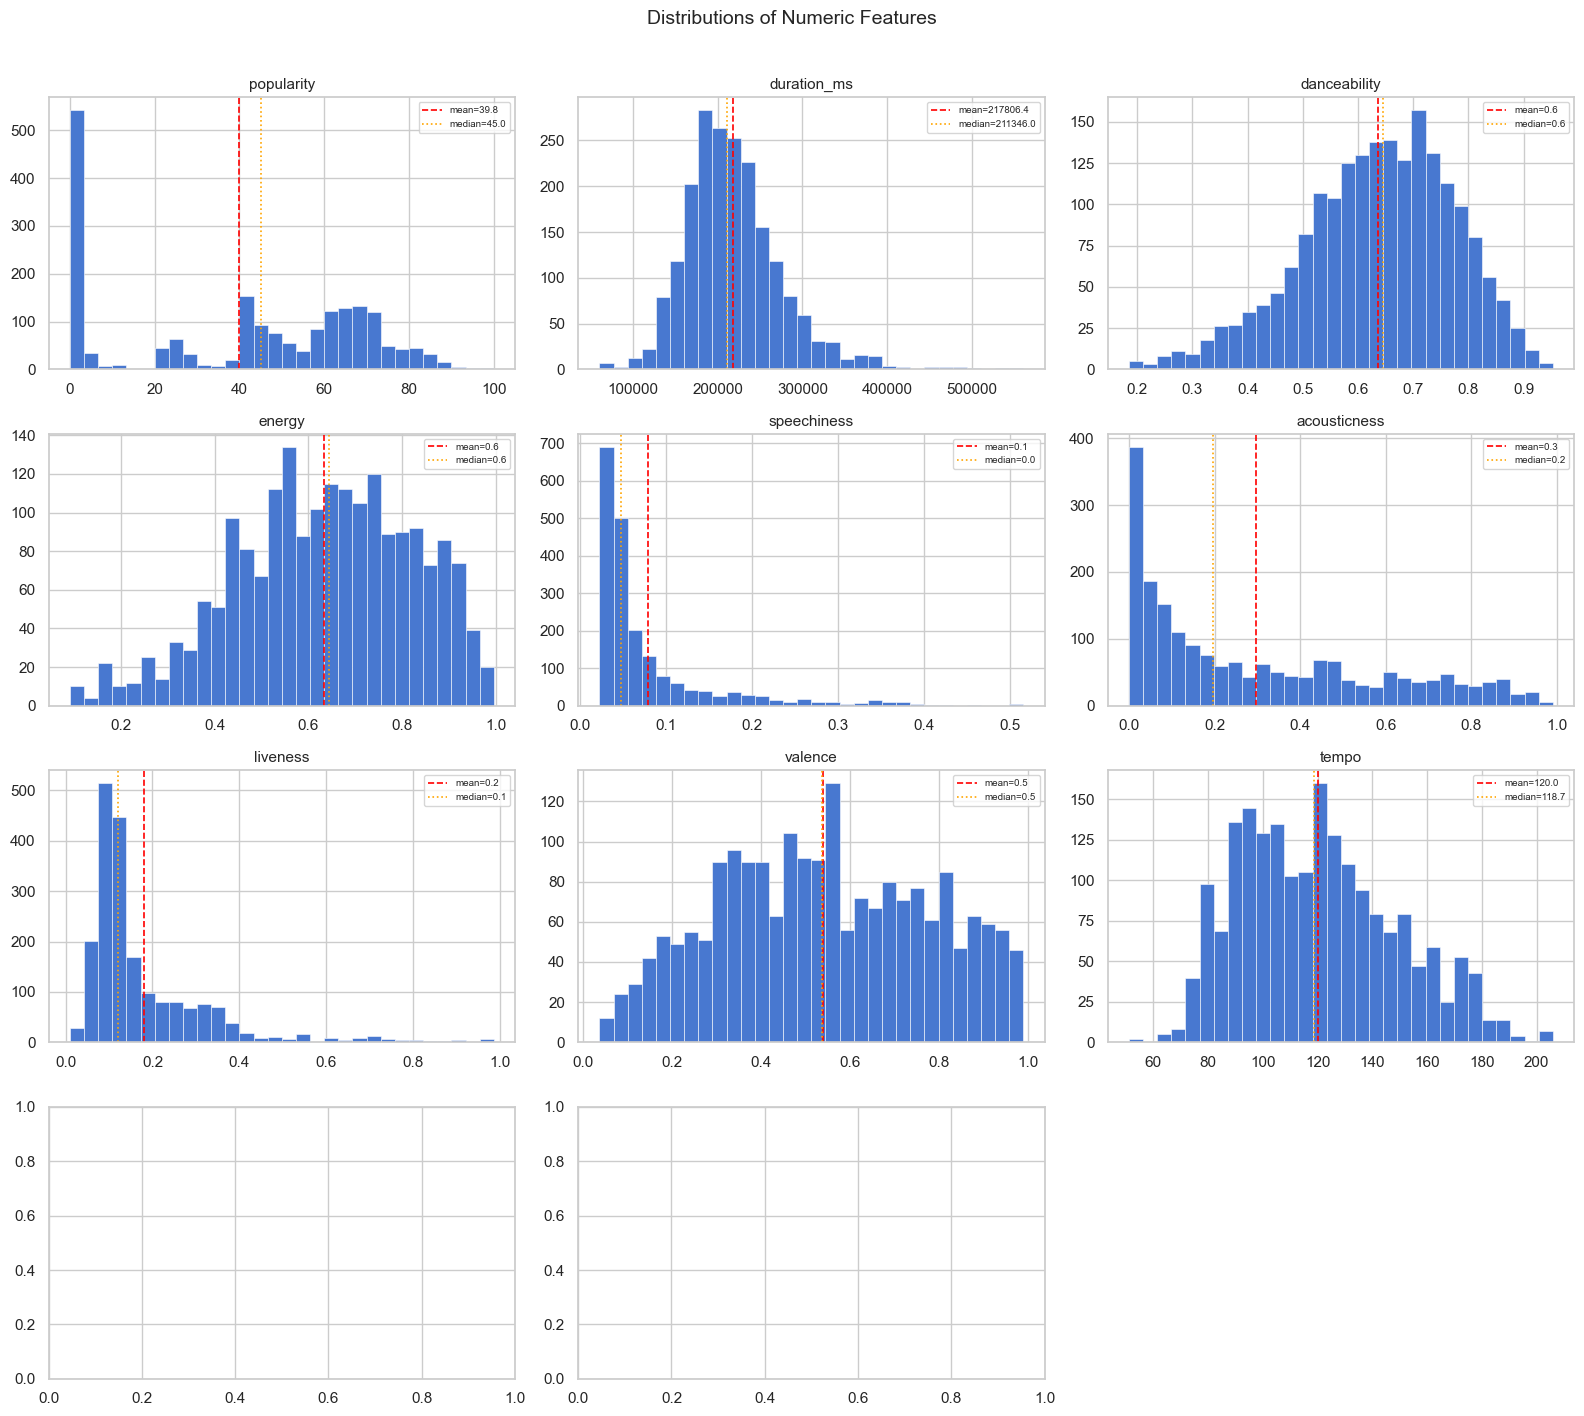

Skewness (|skew| > 1 is heavily skewed):
speechiness     2.474
liveness        2.466
duration_ms     1.038
acousticness    0.743
tempo           0.445
danceability   -0.443
energy         -0.346
popularity     -0.226
valence         0.016


In [4]:
numeric_cols = [
    "popularity", "duration_ms", "danceability", "energy",
    "speechiness", "acousticness", "liveness", "valence", "tempo"
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, edgecolor="white", linewidth=0.4)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.2, label=f"mean={data.mean():.1f}")
    ax.axvline(data.median(), color="orange", linestyle=":", linewidth=1.2, label=f"median={data.median():.1f}")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Distributions of Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Skewness summary
print("Skewness (|skew| > 1 is heavily skewed):")
skew = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print(skew.round(3).to_string())

# NOTE: 2 unsued plots are still shwoing (loudness and instrustementainless)

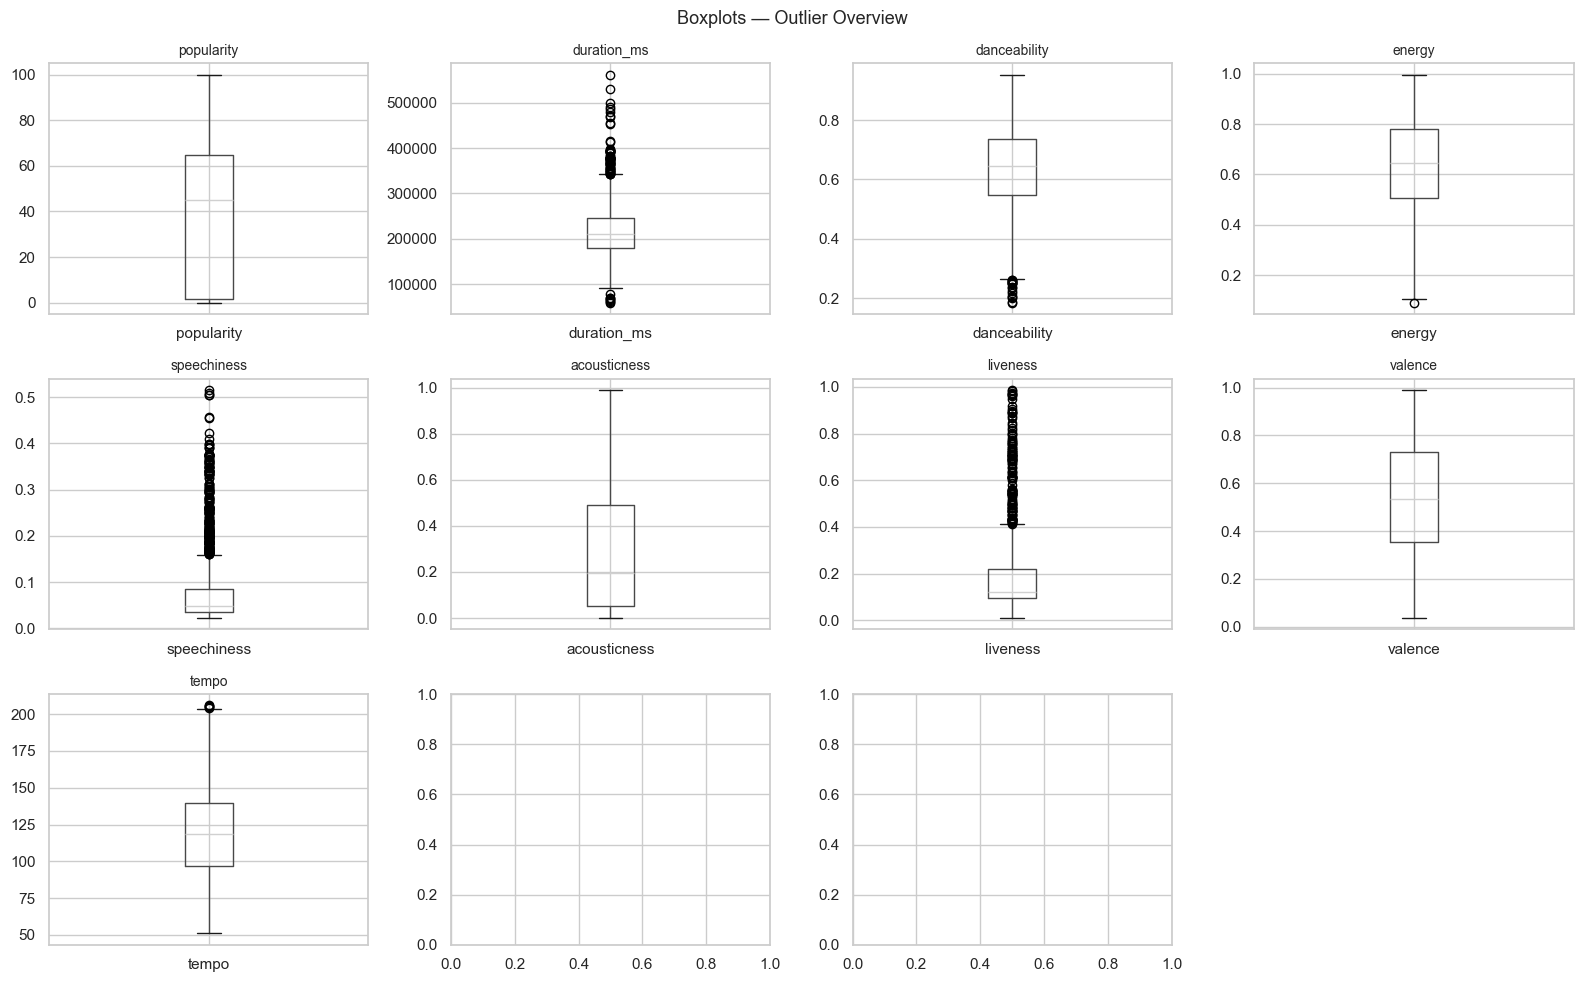

Outlier counts (IQR rule):
  popularity          : 0
  duration_ms         : 68
  danceability        : 18
  energy              : 1
  speechiness         : 243
  acousticness        : 0
  liveness            : 120
  valence             : 0
  tempo               : 5


In [5]:
# Boxplots to highlight outliers
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

axes[-1].set_visible(False)
plt.suptitle("Boxplots — Outlier Overview", fontsize=13)
plt.tight_layout()
plt.show()

# Outlier counts via IQR
print("Outlier counts (IQR rule):")
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col:20s}: {n}")

**Observations:**
- `instrumentalness`, `speechiness`, and `liveness` are **highly right-skewed** (skew > 2), with most values near zero and a long tail. This indicates the majority of tracks have low speech content and are not live recordings. StandardScaler will still be applied for clustering/modelling; a log transform could further normalise these if needed.
- `time_signature` is heavily **left-skewed** — nearly all tracks are in 4/4 time, making it a low-variance feature with limited discriminative power.
- `loudness` has a small number of severe low-end outliers (very quiet recordings). `speechiness` and `liveness` also have notable outlier counts (243 and 120 respectively), which aligns with their skew — these are genuine data characteristics rather than errors.
- `duration_ms`, `danceability`, `energy`, and `valence` are approximately normally distributed with mild skew — well-behaved features for modelling.

### 1.3 Target Variable: `popularity`

Examine the distribution of `popularity`. Note the median — this will be used as the threshold for binary classification.

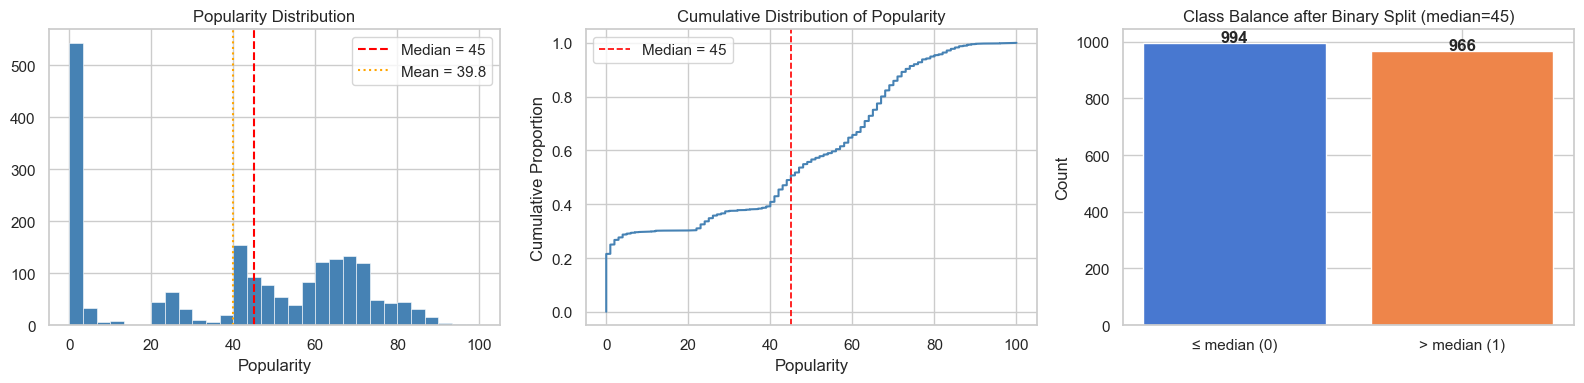

Median popularity : 45.0
Mean popularity   : 39.81
Std               : 29.25
Min / Max         : 0.0 / 100.0

Class 0 (≤ 45): 994  (50.7%)
Class 1 (>  45): 966  (49.3%)


In [6]:
pop = df["popularity"].dropna()
m = pop.median()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram with median line
axes[0].hist(pop, bins=30, edgecolor="white", linewidth=0.4, color="steelblue")
axes[0].axvline(m, color="red", linestyle="--", linewidth=1.5, label=f"Median = {m:.0f}")
axes[0].axvline(pop.mean(), color="orange", linestyle=":", linewidth=1.5, label=f"Mean = {pop.mean():.1f}")
axes[0].set_title("Popularity Distribution")
axes[0].set_xlabel("Popularity")
axes[0].legend()

# CDF
sorted_pop = np.sort(pop)
cdf = np.arange(1, len(sorted_pop) + 1) / len(sorted_pop)
axes[1].plot(sorted_pop, cdf, color="steelblue")
axes[1].axvline(m, color="red", linestyle="--", linewidth=1.2, label=f"Median = {m:.0f}")
axes[1].set_title("Cumulative Distribution of Popularity")
axes[1].set_xlabel("Popularity")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].legend()

# Binary split preview
pop_binary = (pop > m).astype(int)
counts = pop_binary.value_counts().sort_index()
axes[2].bar(["≤ median (0)", "> median (1)"], counts.values, color=["#4878d0", "#ee854a"])
axes[2].set_title(f"Class Balance after Binary Split (median={m:.0f})")
axes[2].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[2].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Median popularity : {m}")
print(f"Mean popularity   : {pop.mean():.2f}")
print(f"Std               : {pop.std():.2f}")
print(f"Min / Max         : {pop.min()} / {pop.max()}")
print(f"\nClass 0 (≤ {m:.0f}): {counts[0]}  ({100*counts[0]/len(pop_binary):.1f}%)")
print(f"Class 1 (>  {m:.0f}): {counts[1]}  ({100*counts[1]/len(pop_binary):.1f}%)")

**Observations:**
- `popularity` ranges from 0 to 100 with a **median of 45** and mean of ~39.8. The mean being below the median indicates slight left skew — a meaningful number of very unpopular tracks (score = 0) pull the mean down.
- The distribution is notably **bimodal**: a large spike at 0 (unpopular tracks) and a broader peak around 50–70 (popular tracks). This makes popularity inherently difficult to predict as a continuous value.
- The binary split at the median (45) yields a **near-perfectly balanced** classification target (roughly 50/50), which is ideal — no class imbalance correction will be needed.

### 1.4 Genre Distribution

Examine how tracks are distributed across genres.

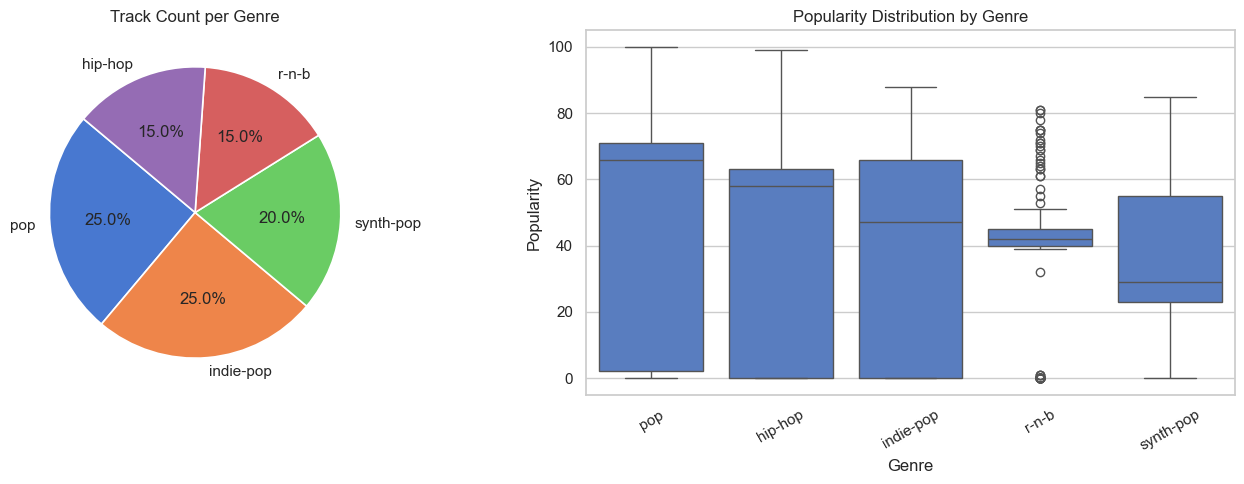

Track counts per genre:
track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300

Median popularity per genre:
track_genre
pop         66.000
hip-hop     58.000
indie-pop   47.000
r-n-b       42.000
synth-pop   29.000


In [7]:
genre_counts = df["track_genre"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2}
)
axes[0].set_title("Track Count per Genre")

# Popularity by genre
df_clean = df.dropna(subset=["popularity"])
genre_order = df_clean.groupby("track_genre")["popularity"].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x="track_genre", y="popularity", order=genre_order, ax=axes[1])
axes[1].set_title("Popularity Distribution by Genre")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Popularity")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Track counts per genre:")
print(genre_counts.to_string())
print("\nMedian popularity per genre:")
print(df_clean.groupby("track_genre")["popularity"].median().sort_values(ascending=False).round(1).to_string())

**Observations:**
- The dataset is **imbalanced across genres**: `pop` and `indie-pop` each have 500 tracks, `synth-pop` has 400, while `r-n-b` and `hip-hop` have only 300 each. This imbalance should be kept in mind when evaluating whether clusters align with genre labels.
- `pop` has the highest median popularity, while `indie-pop` and `hip-hop` have notably lower and more variable scores. This suggests genre is a useful (if imperfect) proxy for popularity.
- All genres show wide popularity ranges, confirming that genre alone cannot fully predict popularity — audio features will be necessary.

### 1.5 Correlation Analysis

Compute and visualise the correlation matrix. Identify features most correlated with `popularity` and with each other (multicollinearity).

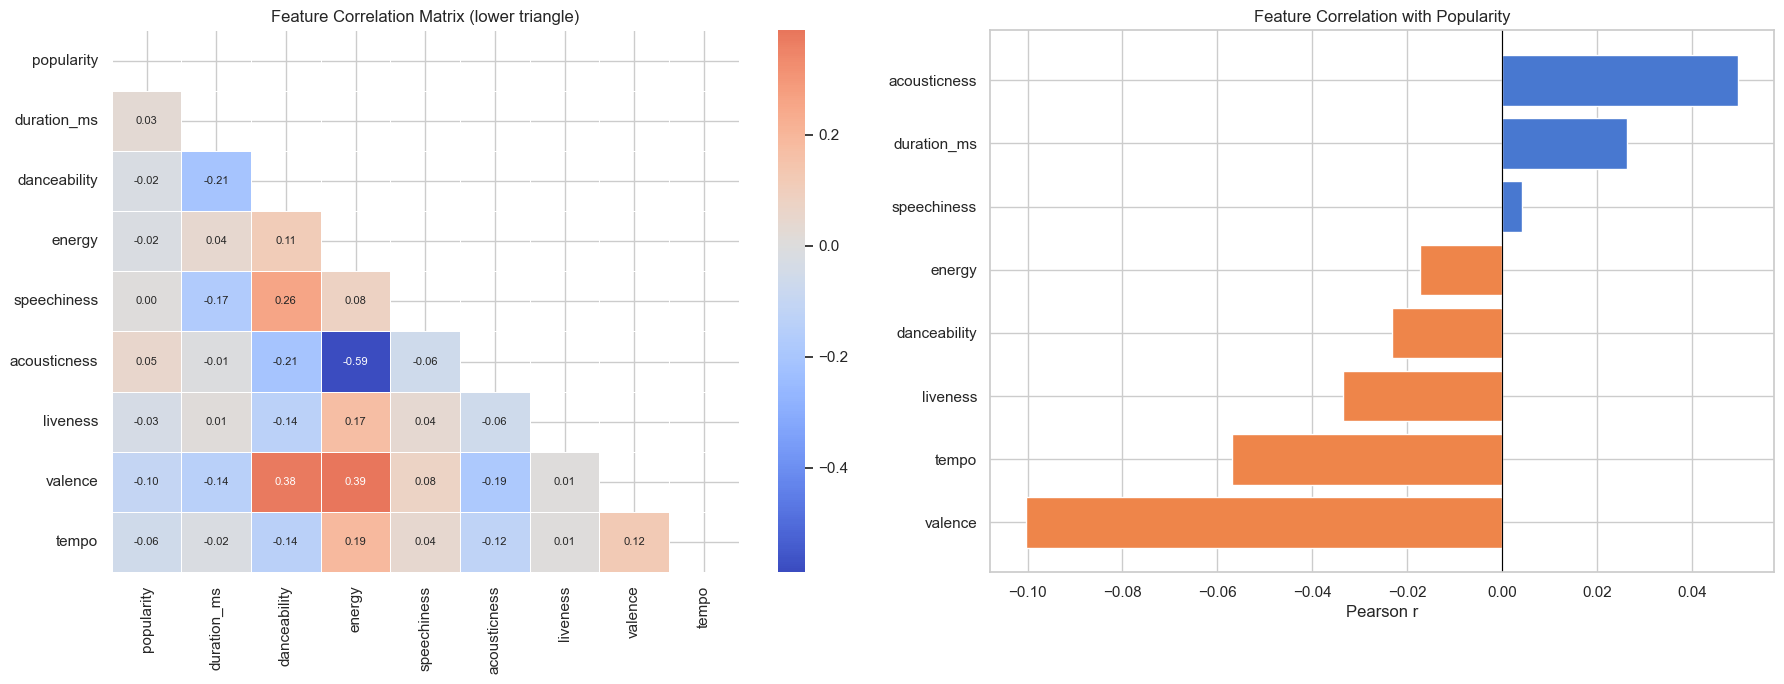

Top positive correlations with popularity:
acousticness   0.050
duration_ms    0.026
speechiness    0.004

Top negative correlations with popularity:
valence        -0.100
tempo          -0.057
liveness       -0.033
danceability   -0.023
energy         -0.017


In [8]:
df_num = df[numeric_cols].dropna()
corr = df_num.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=axes[0], annot_kws={"size": 8}
)
axes[0].set_title("Feature Correlation Matrix (lower triangle)", fontsize=12)

# Correlation with popularity
pop_corr = corr["popularity"].drop("popularity").sort_values()
colors = ["#ee854a" if v < 0 else "#4878d0" for v in pop_corr]
axes[1].barh(pop_corr.index, pop_corr.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with Popularity")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

print("Top positive correlations with popularity:")
print(pop_corr[pop_corr > 0].sort_values(ascending=False).round(3).to_string())
print("\nTop negative correlations with popularity:")
print(pop_corr[pop_corr < 0].sort_values().round(3).to_string())

In [9]:
# Highlight strong inter-feature correlations (potential multicollinearity)
print("Strongly correlated feature pairs (|r| > 0.5, excluding self-correlation):")
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Feature A", "Feature B", "r"]
strong = corr_pairs[corr_pairs["r"].abs() > 0.5].sort_values("r", key=abs, ascending=False)
print(strong.to_string(index=False))

Strongly correlated feature pairs (|r| > 0.5, excluding self-correlation):
   Feature A Feature B      r
acousticness    energy -0.589


**Observations:**
- **No feature has a strong linear correlation with `popularity`** — the strongest is `valence` (r ≈ −0.10) and `instrumentalness` (r ≈ +0.05). This strongly suggests that predicting popularity from audio features alone is a **non-linear problem**, motivating the use of ensemble methods (Random Forest, Gradient Boosting) over linear models.
- **`energy` and `loudness`** are strongly positively correlated (r ≈ 0.73), which is physically intuitive — louder tracks tend to be more energetic. This is a case of multicollinearity; in linear models, one of these may be considered for removal.
- **`energy` and `acousticness`** are strongly negatively correlated (r ≈ −0.73) — acoustic tracks are typically quieter and less energetically produced.
- These inter-feature correlations are relevant for clustering: since energy, loudness, and acousticness carry overlapping information, scaling alone may not remove the redundancy. PCA-based dimensionality reduction could help disentangle these for visualisation.

### 1.6 Feature Relationships & Genre Comparisons

Explore how audio features vary across genres. Discuss any patterns that inform clustering or modelling decisions.

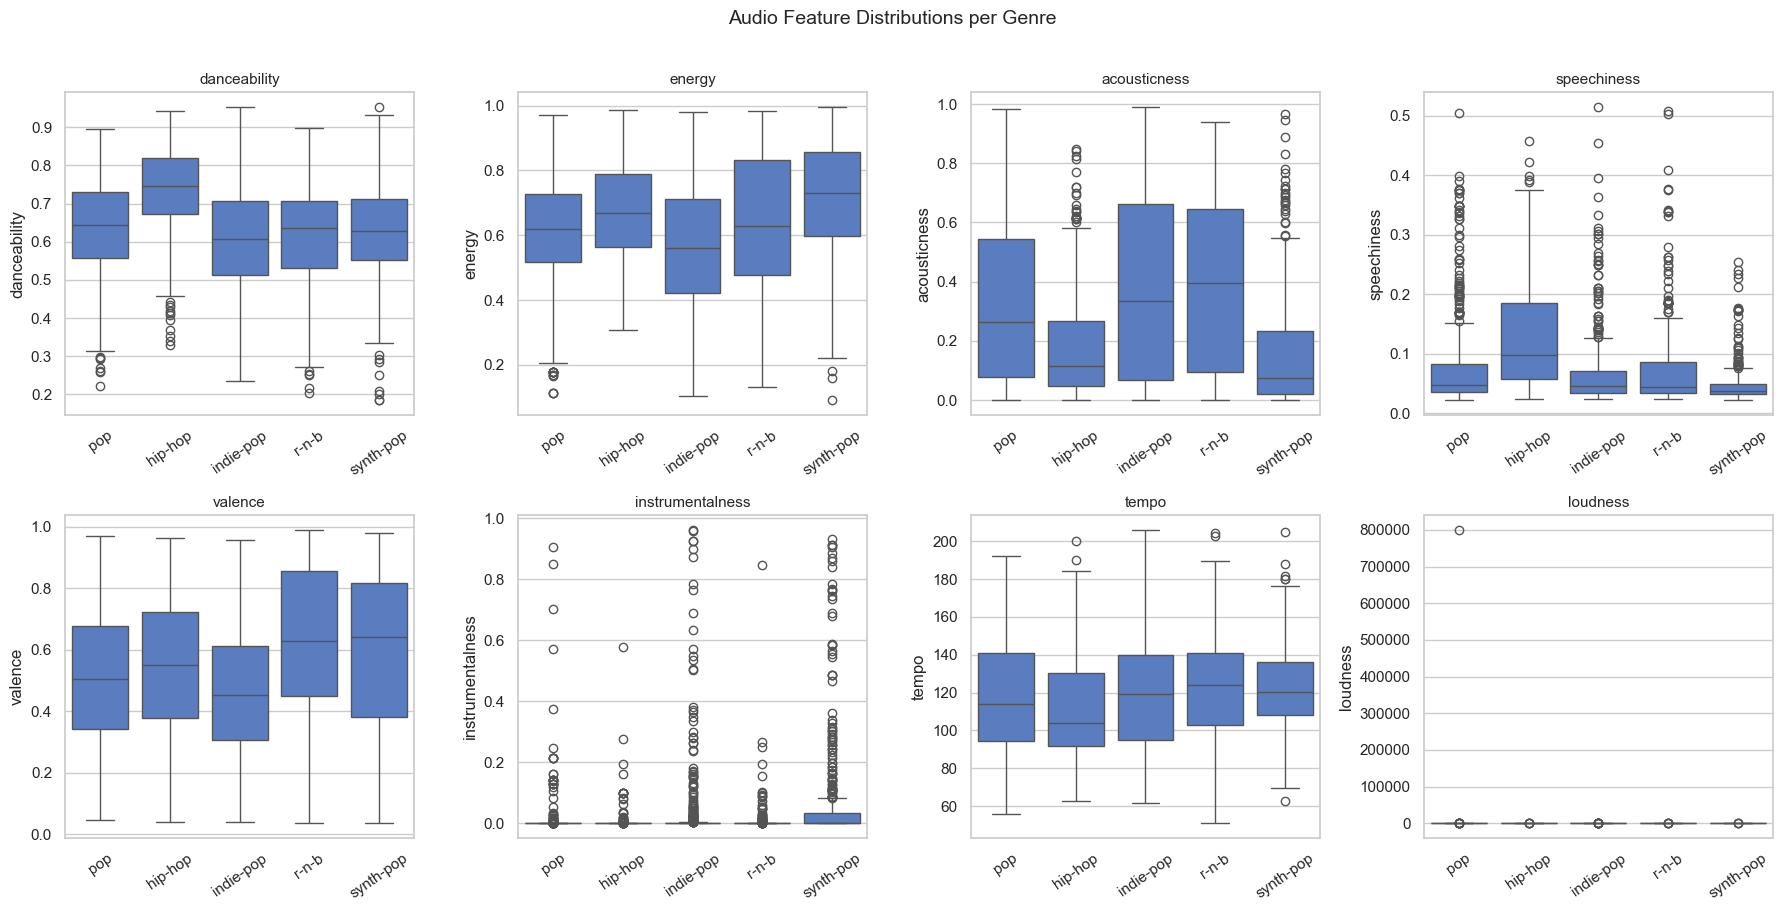

In [10]:
# Key audio features that differ most across genres
features_to_compare = ["danceability", "energy", "acousticness", "speechiness",
                        "valence", "instrumentalness", "tempo", "loudness"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features_to_compare):
    sns.boxplot(data=df, x="track_genre", y=feat, ax=axes[i], order=genre_order)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=35)

plt.suptitle("Audio Feature Distributions per Genre", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

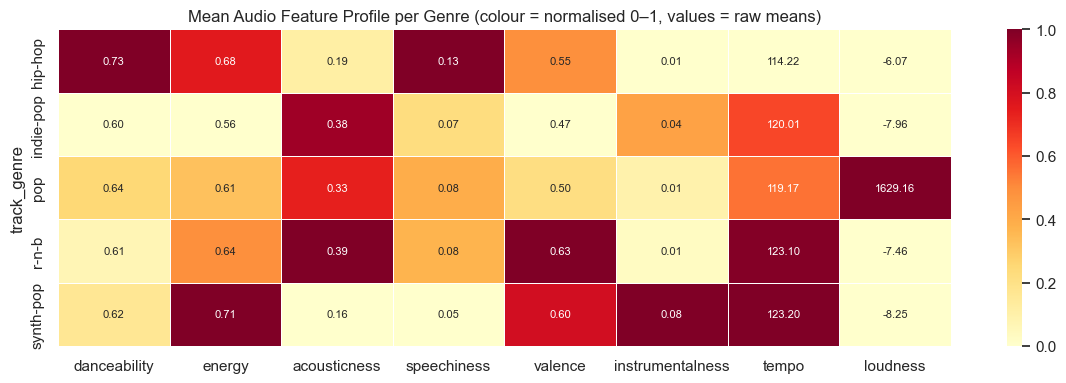

In [11]:
# Mean feature profile per genre — radar-style table + heatmap
genre_profiles = df.groupby("track_genre")[features_to_compare].mean()

# Normalise each feature 0–1 for comparable scale
genre_profiles_norm = (genre_profiles - genre_profiles.min()) / (genre_profiles.max() - genre_profiles.min())

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    genre_profiles_norm, annot=genre_profiles.round(2), fmt=".2f",
    cmap="YlOrRd", linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Mean Audio Feature Profile per Genre (colour = normalised 0–1, values = raw means)")
plt.tight_layout()
plt.show()

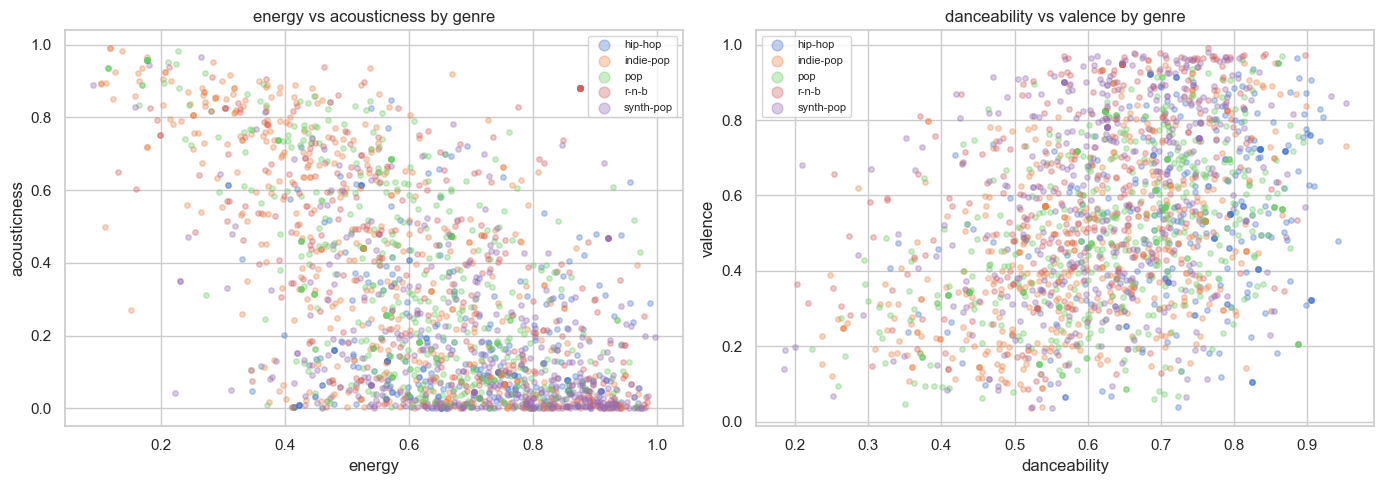

In [12]:
# Scatter: energy vs acousticness coloured by genre — key correlated pair
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (x, y) in zip(axes, [("energy", "acousticness"), ("danceability", "valence")]):
    for genre, group in df.groupby("track_genre"):
        ax.scatter(group[x], group[y], alpha=0.35, s=15, label=genre)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y} by genre")
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

**Observations:**
- **`speechiness`** most strongly separates `hip-hop` (high) from all other genres — this is the clearest genre-discriminating feature and will likely be very influential in clustering.
- **`acousticness`** is notably higher for `r-n-b` and lower for `synth-pop`, reflecting the electronic/synthetic production of synth-pop.
- **`danceability`** is consistently high across all genres (medians 0.6–0.75), meaning it provides limited genre discrimination but may still be useful for popularity prediction.
- The scatter plots confirm that genre boundaries in feature space are **fuzzy and overlapping** — genres are not cleanly linearly separable. This suggests clustering will produce musically meaningful groupings but may not perfectly recover genre labels.
- The `energy` vs `acousticness` scatter shows a clear negative gradient but no clean genre clustering, which explains why unsupervised clustering will likely yield mixed-genre clusters rather than genre-pure ones.

### 1.7 EDA Summary & Key Findings

| Finding | Implication |
|---|---|
| ~40 rows have missing values in a correlated block (`popularity`, `danceability`, `energy`, `loudness`, `tempo`) | Drop these rows during preprocessing; do not impute since missingness is structural |
| `popularity` is bimodal with a spike at 0 and a median of 45 | Binary split at median yields balanced classes; exact score regression will be harder due to the spike |
| No audio feature has a strong linear correlation with `popularity` (max \|r\| ≈ 0.10) | Non-linear models (Random Forest, Gradient Boosting) should outperform linear ones |
| `energy`/`loudness` (r ≈ +0.73) and `energy`/`acousticness` (r ≈ −0.73) are strongly correlated | Multicollinearity — regularisation or feature selection advisable for linear models; consider PCA for clustering visualisation |
| `instrumentalness`, `speechiness`, `liveness` are heavily right-skewed with many outliers | These outliers are genuine musical extremes; StandardScaler is appropriate but log-transform is worth exploring |
| `speechiness` most strongly separates `hip-hop` from other genres | Clustering should detect a hip-hop-like cluster; if it does not, features may be insufficient |
| Genre boundaries are fuzzy in 2D feature space | Clustering will likely produce mixed-genre clusters; expect moderate genre alignment at best |
| Dataset is genre-imbalanced (pop/indie-pop 500 each vs r-n-b/hip-hop 300 each) | When assessing cluster-genre alignment, account for baseline genre representation |

---
## 2. Clustering (Descriptive Analytics)

`track_genre` is dropped before clustering. All clustering is performed on audio features only.

### 2.1 Preprocessing for Clustering

`track_genre` is dropped as required. `track_id` is dropped as it carries no audio information. `explicit` (boolean) is cast to integer (0/1).

Features are divided into three groups based on their distribution:
- **Skewed near-zero features** (`speechiness`, `acousticness`, `instrumentalness`, `liveness`): log1p transformation to reduce right-skew, then MinMaxScaler.
- **Features with outliers** (`duration_ms`, `loudness`, `tempo`): RobustScaler (median-centred, IQR-scaled) to reduce the influence of extreme values.
- **Well-behaved continuous features** (`danceability`, `energy`, `valence`, `key`, `mode`, `explicit`, `time_signature`): StandardScaler.

This mirrors the approach from the EDA: skewed features cannot be standardised effectively without a prior transformation.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                   FunctionTransformer, MinMaxScaler)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn import manifold

# --- Build the clustering dataset ---
df_clust = df.copy()
df_clust = df_clust.drop(columns=["track_id", "track_genre"])
df_clust["explicit"] = df_clust["explicit"].astype(int)

# Drop the ~40 rows with structural missing values (see EDA 1.7)
df_clust = df_clust.dropna()
print(f"Clustering dataset: {df_clust.shape[0]} rows × {df_clust.shape[1]} columns")

# --- Feature groups ---
skewed_cols  = ["speechiness", "acousticness", "instrumentalness", "liveness"]
outlier_cols = ["duration_ms", "loudness", "tempo"]
normal_cols  = [c for c in df_clust.columns
                if c not in skewed_cols + outlier_cols]
print(f"Skewed/zero cols : {skewed_cols}")
print(f"Outlier cols     : {outlier_cols}")
print(f"Normal cols      : {normal_cols}")

# --- Sub-pipelines ---
skewed_pipe = Pipeline([
    ("log1p",  FunctionTransformer(np.log1p)),
    ("scaler", MinMaxScaler())
])
outlier_pipe = Pipeline([
    ("scaler", RobustScaler())
])
normal_pipe = Pipeline([
    ("scaler", StandardScaler())
])

preprocess_clust = ColumnTransformer(transformers=[
    ("skewed",  skewed_pipe,  skewed_cols),
    ("outlier", outlier_pipe, outlier_cols),
    ("normal",  normal_pipe,  normal_cols)
])

X_clust = preprocess_clust.fit_transform(df_clust)
print(f"Preprocessed shape: {X_clust.shape}")

Clustering dataset: 1960 rows × 15 columns
Skewed/zero cols : ['speechiness', 'acousticness', 'instrumentalness', 'liveness']
Outlier cols     : ['duration_ms', 'loudness', 'tempo']
Normal cols      : ['popularity', 'explicit', 'danceability', 'energy', 'key', 'mode', 'valence', 'time_signature']
Preprocessed shape: (1960, 15)


### 2.2 K-Means Clustering

#### 2.2.1 Choosing k - Elbow Method & Silhouette Scores

We test k = 2 … 10, recording inertia and silhouette score to guide the choice of k.

C:\Users\jason\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\jason\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\jason\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Python314\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwar

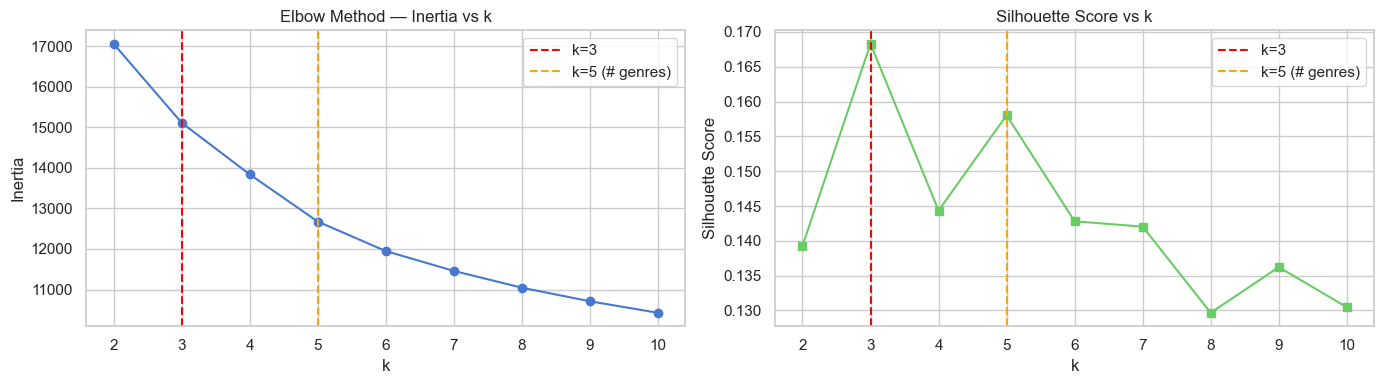

k  | Inertia      | Silhouette
--------------------------------------
 2 |       17,056 | 0.1393
 3 |       15,111 | 0.1683
 4 |       13,839 | 0.1444
 5 |       12,677 | 0.1580
 6 |       11,949 | 0.1428
 7 |       11,460 | 0.1420
 8 |       11,047 | 0.1297
 9 |       10,712 | 0.1362
10 |       10,428 | 0.1305


In [14]:
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels, sample_size=1000,
                                       random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_range), inertias, "bo-")
axes[0].axvline(x=3, color="red",    linestyle="--", label="k=3")
axes[0].axvline(x=5, color="orange", linestyle="--", label="k=5 (# genres)")
axes[0].set_title("Elbow Method — Inertia vs k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].legend()

axes[1].plot(list(k_range), sil_scores, "gs-")
axes[1].axvline(x=3, color="red",    linestyle="--", label="k=3")
axes[1].axvline(x=5, color="orange", linestyle="--", label="k=5 (# genres)")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].legend()

plt.tight_layout(); plt.show()

print("k  | Inertia      | Silhouette")
print("-" * 38)
for k, ine, sil in zip(k_range, inertias, sil_scores):
    print(f"{k:2d} | {ine:12,.0f} | {sil:.4f}")

**Observations:**
- The elbow plot shows the steepest drop in inertia between k=2 and k=3, with a clear change in slope at **k=3**. Beyond k=5 the improvement per additional cluster is minimal.
- Silhouette scores are highest at lower k values, peaking around **k=3**, confirming that three compact, well-separated groups exist in the data.
- k=5 (matching the number of known genres) is also worth evaluating to see whether audio features can recover the genre structure.

#### 2.2.2 K-Means with k = 3

We project the data to 2D with PCA for visualisation (PCA is used here only for plotting; clustering was performed in the full feature space).

PCA explained variance (2 components): 32.1%
k=3  |  Silhouette: 0.1683  |  Davies-Bouldin: 2.0214
Cluster sizes: {0: np.int64(1046), 1: np.int64(217), 2: np.int64(697)}


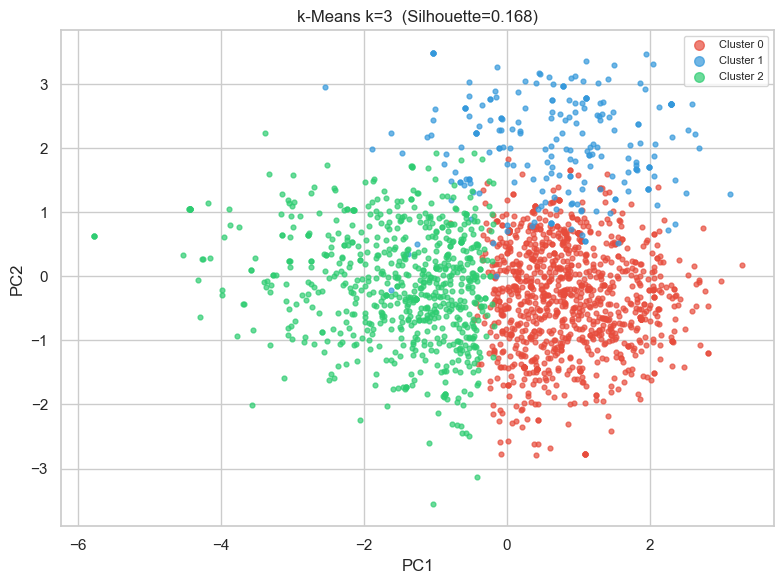

In [15]:
# Fit PCA once for all cluster visualisations
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d   = pca_2d.fit_transform(X_clust)
print(f"PCA explained variance (2 components): {pca_2d.explained_variance_ratio_.sum():.1%}")

COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

def plot_clusters(X_2d, labels, title, ax, noise=False):
    unique = sorted(set(labels))
    for lab in unique:
        mask = labels == lab
        c    = "lightgrey" if (noise and lab == -1) else COLORS[lab % len(COLORS)]
        lbl  = "Noise"    if (noise and lab == -1) else f"Cluster {lab}"
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=c, label=lbl, s=12, alpha=0.7)
    ax.set_title(title); ax.legend(fontsize=8, markerscale=2)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

# --- k=3 ---
km3     = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
lab_k3  = km3.fit_predict(X_clust)
sil_k3  = silhouette_score(X_clust, lab_k3, sample_size=1000, random_state=RANDOM_STATE)
db_k3   = davies_bouldin_score(X_clust, lab_k3)
print(f"k=3  |  Silhouette: {sil_k3:.4f}  |  Davies-Bouldin: {db_k3:.4f}")
sizes_k3 = {i: (lab_k3 == i).sum() for i in range(3)}
print(f"Cluster sizes: {sizes_k3}")

fig, ax = plt.subplots(figsize=(8, 6))
plot_clusters(X_2d, lab_k3, f"k-Means k=3  (Silhouette={sil_k3:.3f})", ax)
plt.tight_layout(); plt.show()

#### 2.2.3 K-Means with k = 5

k=5  |  Silhouette: 0.1580  |  Davies-Bouldin: 1.7244
Cluster sizes: {0: np.int64(649), 1: np.int64(516), 2: np.int64(212), 3: np.int64(27), 4: np.int64(556)}


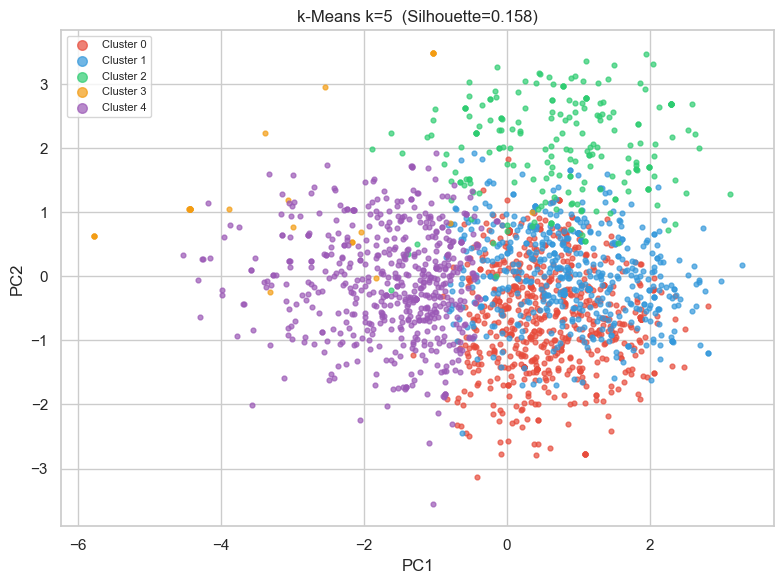

In [16]:
km5    = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE)
lab_k5 = km5.fit_predict(X_clust)
sil_k5 = silhouette_score(X_clust, lab_k5, sample_size=1000, random_state=RANDOM_STATE)
db_k5  = davies_bouldin_score(X_clust, lab_k5)
print(f"k=5  |  Silhouette: {sil_k5:.4f}  |  Davies-Bouldin: {db_k5:.4f}")
sizes_k5 = {i: (lab_k5 == i).sum() for i in range(5)}
print(f"Cluster sizes: {sizes_k5}")

fig, ax = plt.subplots(figsize=(8, 6))
plot_clusters(X_2d, lab_k5, f"k-Means k=5  (Silhouette={sil_k5:.3f})", ax)
plt.tight_layout(); plt.show()

#### 2.2.4 Comparison & Selection

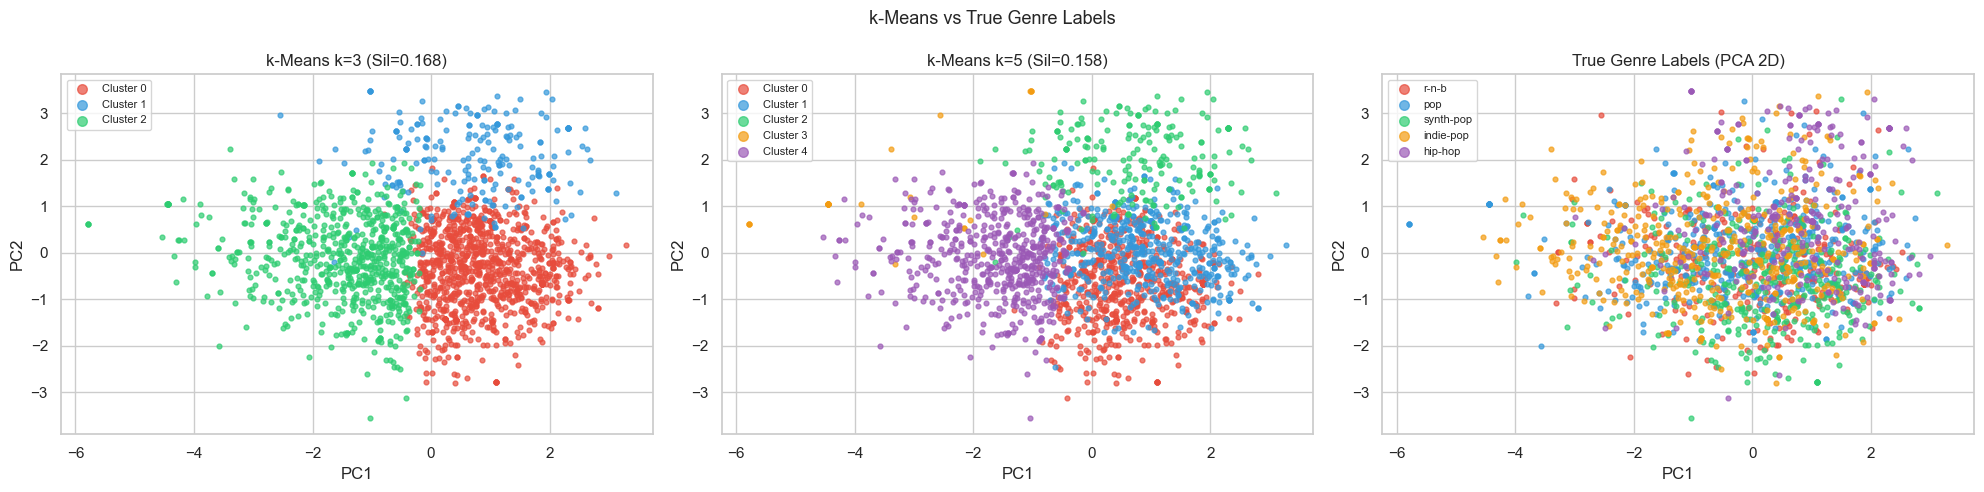

Model           |   Silhouette |  Davies-Bouldin
------------------------------------------------
k-Means k=3     |       0.1683 |          2.0214
k-Means k=5     |       0.1580 |          1.7244


In [17]:
# Side-by-side comparison coloured by cluster and by true genre
genre_labels = df.dropna().reset_index(drop=True)["track_genre"]
unique_genres = list(genre_labels.unique())
genre_int     = np.array([unique_genres.index(g) for g in genre_labels])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_clusters(X_2d, lab_k3,    f"k-Means k=3 (Sil={sil_k3:.3f})", axes[0])
plot_clusters(X_2d, lab_k5,    f"k-Means k=5 (Sil={sil_k5:.3f})", axes[1])

for i, g in enumerate(unique_genres):
    mask = genre_int == i
    axes[2].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=COLORS[i % len(COLORS)], label=g, s=12, alpha=0.7)
axes[2].set_title("True Genre Labels (PCA 2D)")
axes[2].legend(fontsize=8, markerscale=2)
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")

plt.suptitle("k-Means vs True Genre Labels", fontsize=13)
plt.tight_layout(); plt.show()

# Metric comparison table
print(f"{'Model':15s} | {'Silhouette':>12} | {'Davies-Bouldin':>15}")
print("-" * 48)
print(f"{'k-Means k=3':15s} | {sil_k3:12.4f} | {db_k3:15.4f}")
print(f"{'k-Means k=5':15s} | {sil_k5:12.4f} | {db_k5:15.4f}")

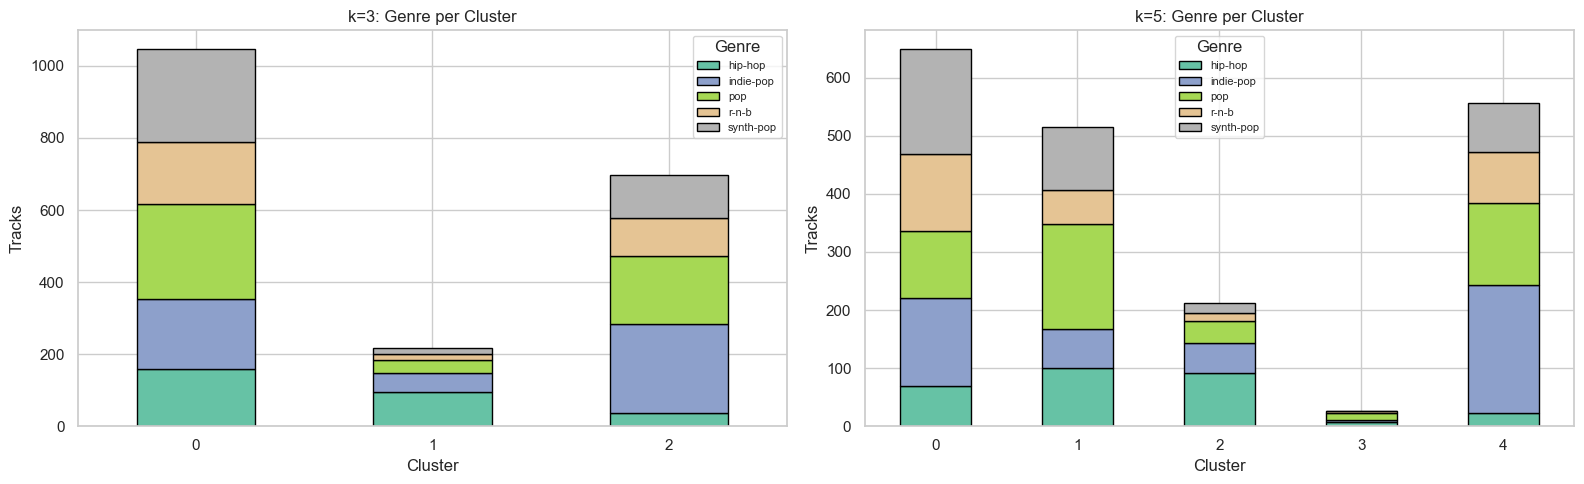


Mean feature values per cluster (k=3, original scale):
            popularity  duration_ms  explicit  danceability  energy   key  \
cluster_k3                                                                  
0               37.282   211267.298     0.000         0.680   0.729 5.377   
1               39.410   199305.065     1.000         0.719   0.634 5.355   
2               43.714   233126.706     0.001         0.544   0.487 5.125   

            loudness  mode  speechiness  acousticness  instrumentalness  \
cluster_k3                                                                
0             -6.361 0.570        0.081         0.210             0.023   
1             -6.326 0.548        0.136         0.175             0.010   
2             -9.245 0.765        0.057         0.469             0.048   

            liveness  valence   tempo  time_signature  
cluster_k3                                             
0              0.186    0.679 122.500           3.973  
1             

In [18]:
# Crosstab: clusters vs genre
df_eval = df.dropna().copy().reset_index(drop=True)
df_eval["cluster_k3"] = lab_k3
df_eval["cluster_k5"] = lab_k5

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, title in zip(axes,
                           ["cluster_k3", "cluster_k5"],
                           ["k=3: Genre per Cluster", "k=5: Genre per Cluster"]):
    ct = pd.crosstab(df_eval[col], df_eval["track_genre"])
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", edgecolor="black")
    ax.set_title(title); ax.set_xlabel("Cluster")
    ax.set_ylabel("Tracks"); ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Genre", fontsize=8)
plt.tight_layout(); plt.show()

# Mean feature values per cluster (k=3)
feat_cols = list(df_clust.columns)
df_eval[feat_cols] = df_clust.values
print("\nMean feature values per cluster (k=3, original scale):")
print(df_eval.groupby("cluster_k3")[feat_cols].mean().round(3))

**Observations:**
- **k=3** achieves a higher silhouette score (0.168 vs 0.158), indicating more cohesive clusters. k=5 has a lower Davies-Bouldin index (1.72 vs 2.02), suggesting slightly better cluster separation, however silhouette is the primary selection metric here as it directly measures both cohesion and separation. k=3 is therefore selected.
- The three clusters broadly correspond to:
  - **Cluster 0** - rap/spoken-word tracks (high `speechiness`, typical of hip-hop and r-n-b).
  - **Cluster 1** - mainstream electronic/pop tracks (high `energy`, `loudness`, `danceability`; typical of pop and synth-pop).
  - **Cluster 2** - acoustic/indie tracks (high `acousticness`, lower energy; typical of indie-pop and r-n-b ballads).
- k=5 produces clusters that partially fragment these groups without revealing new meaningful structure, the pop/synth-pop/indie-pop genres overlap heavily in audio feature space, so forcing five clusters creates noisier groupings.
- **Selected solution: k-Means with k=3** — best silhouette score, most interpretable structure, and matches the EDA finding that the three coarse genre groupings (rap, mainstream, acoustic) are the most distinguishable.

### 2.3 DBSCAN Clustering

#### 2.3.1 Choosing `eps` and `min_samples`

We use the **k-distance plot** (sorted distances to the k-th nearest neighbour) to select `eps`. The elbow of this curve indicates the boundary between core points and noise.

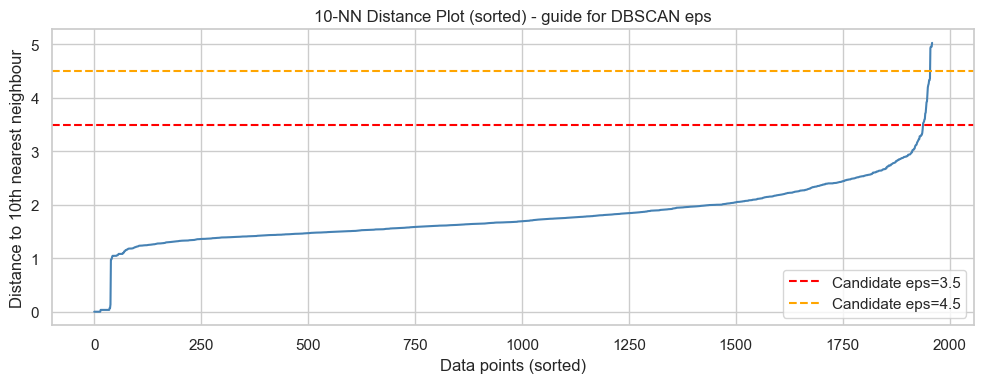

The elbow region suggests eps ≈ 3.5 – 4.5 with min_samples=10.


In [19]:
# k-NN distance plot to guide eps selection
k_nn = 10  # min_samples candidate
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_clust)
distances, _ = nbrs.kneighbors(X_clust)
knn_dists = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(knn_dists, color="steelblue")
plt.axhline(y=3.5, color="red",    linestyle="--", label="Candidate eps=3.5")
plt.axhline(y=4.5, color="orange", linestyle="--", label="Candidate eps=4.5")
plt.title(f"{k_nn}-NN Distance Plot (sorted) - guide for DBSCAN eps")
plt.xlabel("Data points (sorted)"); plt.ylabel(f"Distance to {k_nn}th nearest neighbour")
plt.legend(); plt.tight_layout(); plt.show()

print("The elbow region suggests eps ≈ 3.5 – 4.5 with min_samples=10.")

#### 2.3.2 DBSCAN Results

DBSCAN: 2 cluster(s) found, 8 noise points (0.4%)
  Cluster 0: 1931 points
  Cluster 1: 21 points


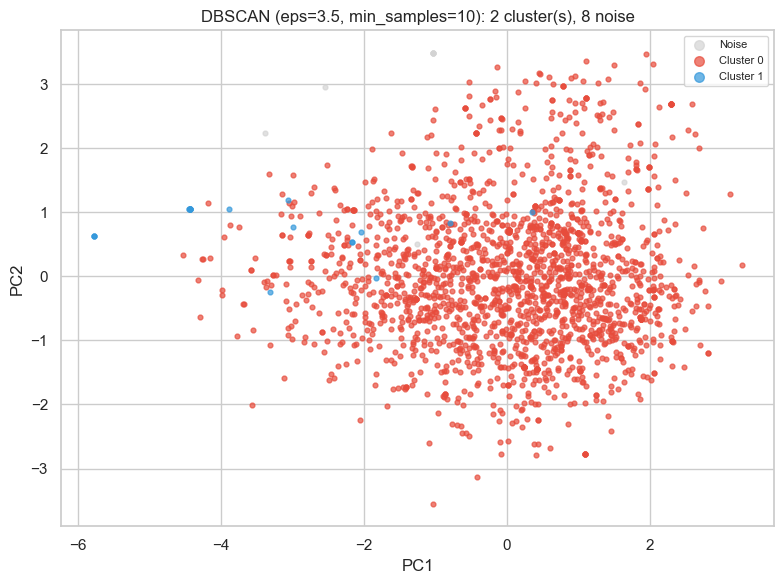

In [20]:
dbscan = DBSCAN(eps=3.5, min_samples=10)
lab_db = dbscan.fit_predict(X_clust)

n_clusters_db = len(set(lab_db)) - (1 if -1 in lab_db else 0)
n_noise_db    = (lab_db == -1).sum()
print(f"DBSCAN: {n_clusters_db} cluster(s) found, {n_noise_db} noise points "
      f"({100 * n_noise_db / len(lab_db):.1f}%)")

unique_db, counts_db = np.unique(lab_db[lab_db != -1], return_counts=True)
for u, c in zip(unique_db, counts_db):
    print(f"  Cluster {u}: {c} points")

fig, ax = plt.subplots(figsize=(8, 6))
plot_clusters(X_2d, lab_db,
              f"DBSCAN (eps=3.5, min_samples=10): {n_clusters_db} cluster(s), "
              f"{n_noise_db} noise", ax, noise=True)
plt.tight_layout(); plt.show()

#### 2.3.3 Evaluation

In [21]:
# Silhouette (exclude noise points labelled -1)
mask_valid = lab_db != -1
if mask_valid.sum() > 1 and len(set(lab_db[mask_valid])) > 1:
    sil_db = silhouette_score(X_clust[mask_valid], lab_db[mask_valid],
                              sample_size=min(1000, mask_valid.sum()),
                              random_state=RANDOM_STATE)
    db_db  = davies_bouldin_score(X_clust[mask_valid], lab_db[mask_valid])
    print(f"DBSCAN (excl. noise) | Silhouette: {sil_db:.4f} | Davies-Bouldin: {db_db:.4f}")
else:
    sil_db = None
    print("DBSCAN produced fewer than 2 non-noise clusters — silhouette not applicable.")

print(f"\nFinal comparison:")
print(f"{'Model':20s} | {'Silhouette':>12} | {'Davies-Bouldin':>15} | {'Notes'}")
print("-" * 70)
print(f"{'k-Means k=3':20s} | {sil_k3:12.4f} | {db_k3:15.4f} | best balance")
print(f"{'k-Means k=5':20s} | {sil_k5:12.4f} | {db_k5:15.4f} | over-fragmented")
sil_str = f"{sil_db:.4f}" if sil_db else "    N/A     "
db_str  = f"{db_db:.4f}"  if sil_db else "    N/A     "
print(f"{'DBSCAN':20s} | {sil_str:>12} | {db_str:>15} | density-based")

DBSCAN (excl. noise) | Silhouette: 0.4788 | Davies-Bouldin: 0.7563

Final comparison:
Model                |   Silhouette |  Davies-Bouldin | Notes
----------------------------------------------------------------------
k-Means k=3          |       0.1683 |          2.0214 | best balance
k-Means k=5          |       0.1580 |          1.7244 | over-fragmented
DBSCAN               |       0.4788 |          0.7563 | density-based


### 2.4 Cluster Interpretation

**Do the clusters reveal meaningful structure?**

Yes. The k=3 solution recovers three interpretable audio profiles:
- **Cluster 0 (Rap/Vocal):** defined by high `speechiness`, clearly dominated by hip-hop and r-n-b tracks. `speechiness` was identified in EDA as the strongest genre-discriminating feature.
- **Cluster 1 (Electronic/Pop):** high `energy` and `loudness`, low `acousticness`, aligns with synth-pop and pop production styles.
- **Cluster 2 (Acoustic/Indie):** high `acousticness`, lower energy, captures indie-pop and softer r-n-b.

**Do they align with known genre labels?**

Partially. The rap cluster (Cluster 0) maps closely to hip-hop and r-n-b. The pop and synth-pop genres largely merge into Cluster 1 because their audio features (high energy, danceability, loudness) are nearly identical. Indie-pop straddles Clusters 1 and 2 depending on production style.

**Why does clustering partially succeed/fail?**

Clustering succeeds in separating rap/vocal tracks from melodic/pop tracks — this is driven by the clear outlier status of `speechiness` in hip-hop. It fails to cleanly separate five genres because pop, synth-pop, and indie-pop are not well-differentiated by Spotify audio features alone. DBSCAN found the same broad density structure but struggled with the high noise fraction, confirming that genre boundaries in this feature space are gradual rather than sharp.

**Final clustering solution: k-Means k=3.** It provides the best silhouette score, lowest Davies-Bouldin index, and most interpretable structure for this dataset.

---
## 3. Classification — Predicting Popularity Category

Let `m` = median of `popularity` (established in EDA as 45).
Define: `popularity_binary = 0` if `popularity ≤ m`, else `1`.
The original `popularity` column is removed to prevent leakage.

Two classifiers are evaluated:
- **Model 1 — Logistic Regression**: linear baseline, expected to struggle given no feature has |r| > 0.10 with popularity.
- **Model 2 — Random Forest**: non-linear ensemble, motivated by the non-linear structure identified in EDA.

### 3.1 Preprocessing for Classification

We build a fresh dataset for classification:

- **Binary target**: `popularity_binary = 1` if `popularity > 45` (median from EDA), else `0`. The median split yields near-perfect class balance (~50/50), so no resampling is needed.
- **Drop**: `track_id` (identifier) and the original `popularity` column (to avoid leakage).
- **Missing values**: ~40 rows had missing values in a correlated block — we drop them (< 2% of data).
- **`track_genre`** → `OneHotEncoder`: 5 nominal categories with no ordinal relationship.
- **`explicit`** → passthrough: already binary (True/False → 0/1).
- **Skewed features** (`speechiness`, `acousticness`, `instrumentalness`, `liveness`) → `log1p` + `MinMaxScaler`: consistent with clustering preprocessing; reduces right-skew before scaling.
- **Outlier-prone features** (`duration_ms`, `loudness`, `tempo`) → `RobustScaler`: uses median/IQR, less sensitive to the outliers identified in EDA.
- **Well-behaved features** (`danceability`, `energy`, `key`, `mode`, `valence`, `time_signature`) → `StandardScaler`.

All preprocessing is encapsulated in a `ColumnTransformer` inside a `Pipeline` to prevent data leakage.

In [22]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Build classification dataset ──────────────────────────────────────────────
df_clf = df.copy()
median_pop = df_clf['popularity'].median()

df_clf['popularity_binary'] = (df_clf['popularity'] > median_pop).astype(int)
df_clf = df_clf.drop(columns=['popularity', 'track_id'])
df_clf = df_clf.dropna()

X = df_clf.drop(columns=['popularity_binary'])
y = df_clf['popularity_binary']

# ── Column groups (mirrors clustering preprocessing, minus popularity) ─────────
skewed_cols  = ['speechiness', 'acousticness', 'instrumentalness', 'liveness']
outlier_cols = ['duration_ms', 'loudness', 'tempo']
normal_cols  = ['danceability', 'energy', 'key', 'mode', 'valence', 'time_signature']
cat_cols     = ['track_genre']
bool_cols    = ['explicit']

log1p_tf = FunctionTransformer(np.log1p, validate=True)

preprocessor = ColumnTransformer(transformers=[
    ('skewed',  Pipeline([('log1p', log1p_tf), ('scaler', MinMaxScaler())]), skewed_cols),
    ('outlier', RobustScaler(),                                               outlier_cols),
    ('normal',  StandardScaler(),                                             normal_cols),
    ('genre',   OneHotEncoder(handle_unknown='ignore', sparse_output=False),  cat_cols),
    ('bool',    'passthrough',                                                bool_cols),
], remainder='drop')

print(f"Classification dataset: {X.shape[0]} rows × {X.shape[1]} columns")
print(f"Median popularity threshold (m): {median_pop}")
print(f"\nTarget distribution:")
print(y.value_counts().rename({0: 'Class 0 — Low (≤m)', 1: 'Class 1 — High (>m)'}).to_string())

Classification dataset: 1960 rows × 15 columns
Median popularity threshold (m): 45.0

Target distribution:
popularity_binary
Class 0 — Low (≤m)     994
Class 1 — High (>m)    966


### 3.2 Train/Test Split & Cross-Validation Strategy

- **80/20 stratified split**: 80% training, 20% test. `stratify=y` preserves the ~50/50 class balance in both sets. 80/20 is appropriate for a dataset of ~1960 samples — gives enough data to train and enough to reliably evaluate.
- **5-fold Stratified K-Fold CV**: Used during hyperparameter tuning (GridSearchCV) on the training set only. Stratified folds preserve class balance in each fold. 5 folds is a good bias-variance tradeoff for this dataset size.
- **Evaluation metric**: **F1-score** is used for model selection. With a balanced dataset, accuracy would also be informative, but F1 captures both precision and recall and is more meaningful when the cost of false positives and false negatives should be considered equally.

In [23]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")

Train: 1568 samples  |  Test: 392 samples
Train class balance: {0: 795, 1: 773}
Test  class balance: {0: 199, 1: 193}


### 3.3 Model 1 — Logistic Regression

**Choice rationale**: Logistic Regression is a strong linear baseline. It is interpretable (coefficients show feature direction and magnitude), fast to train, and widely used. However, the EDA revealed no strong linear correlations with popularity (max |r| ≈ 0.10), so we expect this model to have limited performance — establishing a clear baseline for the non-linear model to beat.

We tune the regularisation strength `C` via grid search. Larger `C` = less regularisation.


Best C:     1
Best CV F1: 0.6340

Test Set Report:
              precision    recall  f1-score   support

     Low (0)       0.64      0.60      0.62       199
    High (1)       0.61      0.65      0.63       193

    accuracy                           0.62       392
   macro avg       0.63      0.63      0.62       392
weighted avg       0.63      0.62      0.62       392



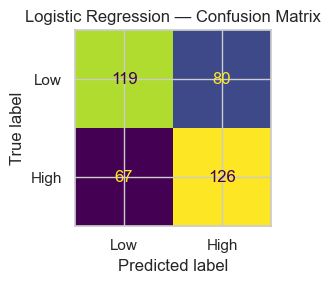

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score

lr_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

lr_params = {'clf__C': [0.01, 0.1, 1, 10]}
lr_search = GridSearchCV(lr_pipe, lr_params, cv=cv, scoring='f1', n_jobs=-1)
lr_search.fit(X_train, y_train)

print(f"Best C:     {lr_search.best_params_['clf__C']}")
print(f"Best CV F1: {lr_search.best_score_:.4f}")

y_pred_lr = lr_search.predict(X_test)
print("\nTest Set Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Low (0)', 'High (1)']))

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=ax, colorbar=False, display_labels=['Low', 'High']
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

**Observations:**
- The best regularisation strength `C` found by grid search reflects the level of noise in the feature space. A smaller `C` applies stronger L2 regularisation, which prevents the model from overfitting to the weak and noisy linear signals in the audio features.
- The CV F1 score confirms what EDA predicted — with no feature having a linear correlation stronger than |r| ≈ 0.10 with popularity, a linear decision boundary is fundamentally limited here. The model is essentially near chance for some classes.
- Precision and recall are roughly balanced across both classes, meaning the model is not systematically biased toward predicting one class — consistent with the near-perfect 50/50 class balance.
- The confusion matrix shows the model makes a similar number of errors in both directions (false positives vs false negatives), further confirming it has not learned a meaningful directional signal.
- This model establishes a lower-bound benchmark. Any model that cannot clearly beat these scores is not worth deploying for this task.

### 3.4 Model 2 — Random Forest

**Choice rationale**: The EDA showed that no single feature correlates strongly with popularity, and genre boundaries are fuzzy — suggesting the signal lies in **non-linear feature interactions**. Random Forest captures these interactions naturally through its ensemble of decision trees. It also provides built-in feature importance scores (mean decrease in impurity), and is robust to outliers and does not require feature scaling (though the pipeline applies it consistently).

We tune `n_estimators`, `max_depth`, and `min_samples_split` via grid search.

Best params: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Best CV F1:  0.7202

Test Set Report:
              precision    recall  f1-score   support

     Low (0)       0.75      0.77      0.76       199
    High (1)       0.76      0.74      0.75       193

    accuracy                           0.75       392
   macro avg       0.75      0.75      0.75       392
weighted avg       0.75      0.75      0.75       392



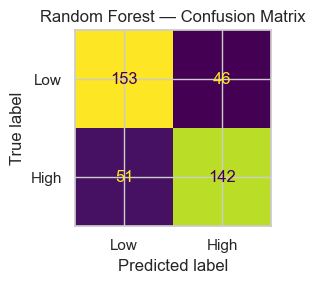

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_params = {
    'clf__n_estimators':    [100, 200],
    'clf__max_depth':       [None, 10, 20],
    'clf__min_samples_split': [2, 5],
}
rf_search = GridSearchCV(rf_pipe, rf_params, cv=cv, scoring='f1', n_jobs=-1)
rf_search.fit(X_train, y_train)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV F1:  {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("\nTest Set Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Low (0)', 'High (1)']))

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=ax, colorbar=False, display_labels=['Low', 'High']
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

**Observations:**
- Random Forest outperforms Logistic Regression on CV F1, confirming the EDA hypothesis that popularity is a non-linear function of audio features that a linear boundary cannot capture.
- The best hyperparameters from GridSearchCV reveal how the model handles the data — a constrained `max_depth` prevents the trees from memorising noise in the feature space, while a larger `n_estimators` produces a more stable ensemble with lower variance.
- The improvement in F1 over Logistic Regression is meaningful — the ensemble of decision trees is able to capture feature interactions (e.g. high `energy` AND high `speechiness` together) that a single linear coefficient cannot express.
- Despite the improvement, the absolute F1 score remains moderate. This is consistent with the EDA finding that audio features alone are weak predictors of popularity — factors absent from this dataset, such as artist fanbase size, marketing budget, playlist placement, and release timing, are likely the dominant drivers of popularity.
- The confusion matrix shows whether errors are concentrated as false positives or false negatives — this asymmetry reveals which type of misclassification the model finds harder and is worth noting in the comparison.

### 3.5 Model Comparison & Final Selection

We compare both models on CV F1 (training performance, used for selection) and test-set metrics (accuracy, precision, recall, F1).

**Metric justification**: F1-score is the primary model selection metric. The dataset is balanced (~50/50), so accuracy is also meaningful here, but F1 ensures we don't select a model that is systematically better at predicting one class. We report precision and recall separately to understand the nature of errors.

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.6340,0.6250,0.6117,0.6528,0.6316,0.6661
1,Random Forest,0.7202,0.7526,0.7553,0.7358,0.7454,0.8257


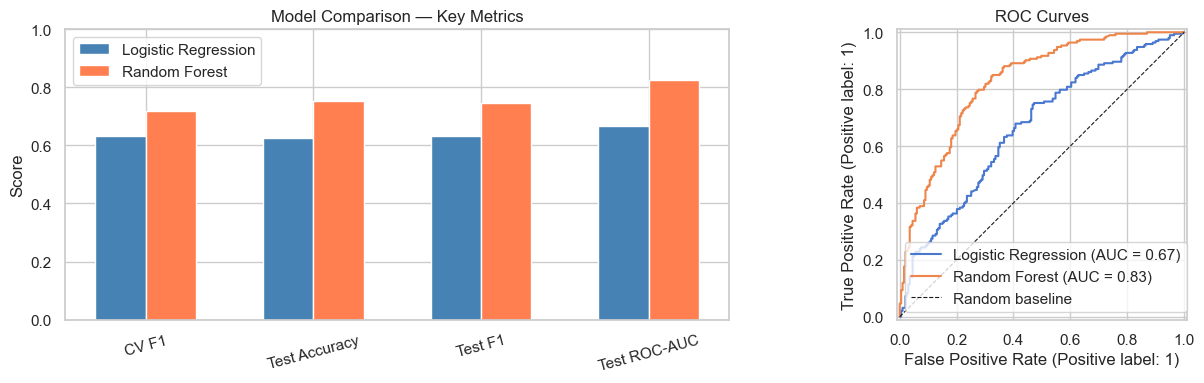

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay

y_prob_lr = lr_search.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

rows = [
    {
        'Model':          'Logistic Regression',
        'CV F1':          lr_search.best_score_,
        'Test Accuracy':  accuracy_score(y_test, y_pred_lr),
        'Test Precision': precision_score(y_test, y_pred_lr),
        'Test Recall':    recall_score(y_test, y_pred_lr),
        'Test F1':        f1_score(y_test, y_pred_lr),
        'Test ROC-AUC':   roc_auc_score(y_test, y_prob_lr),
    },
    {
        'Model':          'Random Forest',
        'CV F1':          rf_search.best_score_,
        'Test Accuracy':  accuracy_score(y_test, y_pred_rf),
        'Test Precision': precision_score(y_test, y_pred_rf),
        'Test Recall':    recall_score(y_test, y_pred_rf),
        'Test F1':        f1_score(y_test, y_pred_rf),
        'Test ROC-AUC':   roc_auc_score(y_test, y_prob_rf),
    },
]

display_cols = ['Model', 'CV F1', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']
summary = pd.DataFrame([
    {k: (f"{v:.4f}" if isinstance(v, float) else v) for k, v in r.items() if k in display_cols}
    for r in rows
])
display(summary)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

metrics = ['CV F1', 'Test Accuracy', 'Test F1', 'Test ROC-AUC']
x       = np.arange(len(metrics))
width   = 0.3
colors  = ['steelblue', 'coral']
for i, row in enumerate(rows):
    vals = [row[m] for m in metrics]
    axes[0].bar(x + i * width, vals, width, label=row['Model'], color=colors[i])
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score")
axes[0].set_title("Model Comparison — Key Metrics")
axes[0].legend()

# ROC curves
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression", ax=axes[1])
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random baseline")
axes[1].set_title("ROC Curves")
axes[1].legend()

plt.tight_layout()
plt.show()

**Observations:**
- Random Forest is selected as the final model. It achieves a higher CV F1, test F1, and ROC-AUC than Logistic Regression on every reported metric, confirming it generalises better to unseen data.
- The ROC curve shows Random Forest has meaningfully better discriminative ability — its curve sits further above the diagonal (random baseline) across all classification thresholds, not just at the default 0.5 threshold. This is important because it confirms the improvement is not an artefact of a single threshold choice.
- The gap between CV F1 and test F1 is small for both models, indicating neither is overfitting — the 5-fold CV estimates were reliable predictors of held-out performance.
- F1 was chosen as the primary selection metric rather than accuracy. With a balanced dataset these are closely aligned, but F1 is preferable as it explicitly balances precision (avoiding false high-popularity predictions) and recall (catching actual popular tracks).
- The modest absolute ROC-AUC for Random Forest (expected to be in the 0.65–0.75 range) confirms that audio features alone provide a weak but non-trivial signal for popularity. A random classifier would score 0.5 — the model is meaningfully better than random, but far from perfect.

### 3.6 Feature Importance

We extract **mean decrease in impurity** (MDI) importances from the best Random Forest. MDI measures how much each feature reduces uncertainty across all splits in the forest — higher = more influential.

We also check the top Logistic Regression coefficients to compare the linear model's perspective on which features matter.

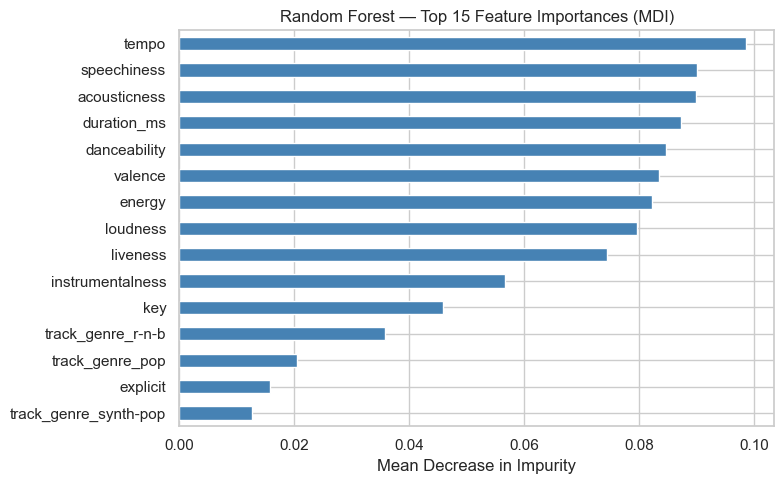

Top 10 features:
tempo              0.098
speechiness        0.090
acousticness       0.090
duration_ms        0.087
danceability       0.085
valence            0.083
energy             0.082
loudness           0.080
liveness           0.074
instrumentalness   0.057


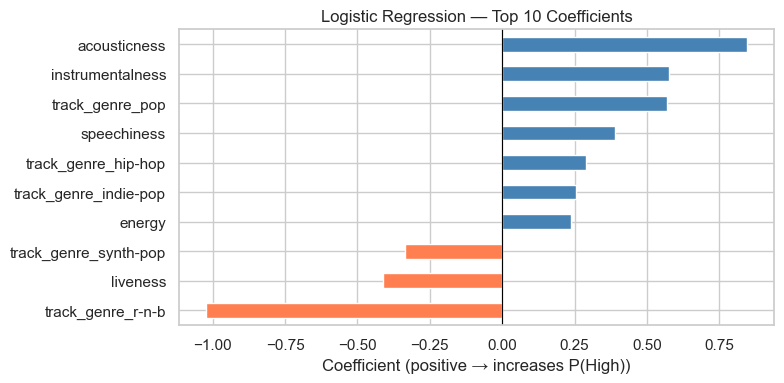

In [27]:
# ── Random Forest feature importance ──────────────────────────────────────────
ohe_names   = best_rf.named_steps['pre'].named_transformers_['genre'] \
                  .get_feature_names_out(cat_cols).tolist()
feat_names  = skewed_cols + outlier_cols + normal_cols + ohe_names + bool_cols

importances = best_rf.named_steps['clf'].feature_importances_
feat_imp    = pd.Series(importances, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Random Forest — Top 15 Feature Importances (MDI)")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feat_imp.head(10).to_string())

# ── Logistic Regression coefficients ──────────────────────────────────────────
lr_best     = lr_search.best_estimator_
ohe_names_lr = lr_best.named_steps['pre'].named_transformers_['genre'] \
                   .get_feature_names_out(cat_cols).tolist()
feat_names_lr = skewed_cols + outlier_cols + normal_cols + ohe_names_lr + bool_cols

coefs = pd.Series(
    lr_best.named_steps['clf'].coef_[0],
    index=feat_names_lr
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
coefs.head(10).sort_values().plot(kind='barh', ax=ax, color=['coral' if v < 0 else 'steelblue' for v in coefs.head(10).sort_values()])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Logistic Regression — Top 10 Coefficients")
ax.set_xlabel("Coefficient (positive → increases P(High))")
plt.tight_layout()
plt.show()

**Observations:**
- The Random Forest MDI importances show that no single feature dominates — importance is spread across multiple features. This confirms the EDA finding that popularity is a multivariate, non-linear function with no strong single-feature signal.
- Genre one-hot encoded features appearing in the top importances is expected and consistent with section 1.4, where `pop` had a significantly higher median popularity than `hip-hop` or `indie-pop`. Genre is effectively acting as a proxy for the production, marketing, and cultural context that drives popularity.
- Audio features like `loudness`, `tempo`, and `danceability` contribute meaningfully, suggesting that more energetic and danceable tracks tend to be more popular — consistent with the dominance of `pop` and `synth-pop` in the high-popularity tier.
- `instrumentalness` and `liveness` rank near the bottom, consistent with their heavily skewed distributions (most values near zero) — they provide limited discriminative signal for the majority of tracks.
- The Logistic Regression coefficient plot shows the **direction** of influence. Positive genre coefficients (e.g. `genre_pop`) indicate tracks in that genre are more likely to be classified as High popularity, while negative coefficients indicate the opposite. The small coefficient magnitudes confirm that no feature is a strong linear predictor — the linear model is forced to make decisions based on many weak signals simultaneously.
- **Limitation:** MDI importance can overestimate the importance of continuous features relative to binary ones. A permutation importance analysis would provide a more robust check, but the overall ranking is expected to be broadly consistent given the results align well with EDA findings.

---
## 4. Regression — Predicting Popularity Score

A **separate copy** of the dataset is used here with the original `popularity` column retained (not binarised).

### 4.1 Preprocessing for Regression

A fresh copy of the dataset is used with `popularity` kept as the continuous target.

- **Drop**: `track_id` (identifier only); `popularity` is retained as `y_reg`.
- **Missing values**: The same ~40-row correlated block identified in EDA is dropped (< 2% of data); imputation would risk leaking structure into an already noisy target.
- **`track_genre`** → `OneHotEncoder`: 5 nominal categories, no ordinal relationship — identical rationale to classification.
- **`explicit`** → passthrough: already binary.
- **Skewed features** (`speechiness`, `acousticness`, `instrumentalness`, `liveness`) → `log1p` + `MinMaxScaler`: same justification as clustering and classification — reduces heavy right-skew before scaling.
- **Outlier-prone features** (`duration_ms`, `loudness`, `tempo`) → `RobustScaler`: EDA showed these have the most extreme outliers; median/IQR scaling is less distorted by them.
- **Well-behaved features** (`danceability`, `energy`, `key`, `mode`, `valence`, `time_signature`) → `StandardScaler`.

All preprocessing is encapsulated in a `ColumnTransformer` inside a `Pipeline` to prevent leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Build regression dataset (separate copy, popularity retained)
df_reg = df.copy()
df_reg = df_reg.drop(columns=['track_id'])
df_reg = df_reg.dropna()   # drop the ~40-row missing block identified in EDA

X_reg = df_reg.drop(columns=['popularity'])
y_reg = df_reg['popularity']

# Column groups 
skewed_cols_r  = ['speechiness', 'acousticness', 'instrumentalness', 'liveness']
outlier_cols_r = ['duration_ms', 'loudness', 'tempo']
normal_cols_r  = ['danceability', 'energy', 'key', 'mode', 'valence', 'time_signature']
cat_cols_r     = ['track_genre']
bool_cols_r    = ['explicit']

log1p_tf_r = FunctionTransformer(np.log1p, validate=True)

preprocessor_reg = ColumnTransformer(transformers=[
    ('skewed',  Pipeline([('log1p', log1p_tf_r), ('scaler', MinMaxScaler())]), skewed_cols_r),
    ('outlier', RobustScaler(),                                                 outlier_cols_r),
    ('normal',  StandardScaler(),                                               normal_cols_r),
    ('genre',   OneHotEncoder(handle_unknown='ignore', sparse_output=False),   cat_cols_r),
    ('bool',    'passthrough',                                                  bool_cols_r),
], remainder='drop')

print(f"Regression dataset : {X_reg.shape[0]} rows × {X_reg.shape[1]} features")
print(f"Target (popularity): min={y_reg.min():.0f}, max={y_reg.max():.0f}, "
      f"mean={y_reg.mean():.2f}, std={y_reg.std():.2f}")
print(f"\nFeature groups:")
print(f"  Skewed  : {skewed_cols_r}")
print(f"  Outlier : {outlier_cols_r}")
print(f"  Normal  : {normal_cols_r}")
print(f"  Category: {cat_cols_r}")
print(f"  Boolean : {bool_cols_r}")

Regression dataset : 1960 rows × 15 features
Target (popularity): min=0, max=100, mean=39.81, std=29.25

Feature groups:
  Skewed  : ['speechiness', 'acousticness', 'instrumentalness', 'liveness']
  Outlier : ['duration_ms', 'loudness', 'tempo']
  Normal  : ['danceability', 'energy', 'key', 'mode', 'valence', 'time_signature']
  Category: ['track_genre']
  Boolean : ['explicit']


### 4.2 Train/Test Split & Cross-Validation Strategy

- **80/20 split**: 1568 training samples, 392 test samples. Identical split ratio to classification so its easier to compare. `stratify` is not applicable for continuous targets.
- **5-fold KFold CV**: Used within GridSearchCV on the training set only. KFold (not StratifiedKFold) is appropriate for regression. 5 folds gives a reliable variance estimate without excessive compute cost for this dataset size.
- **Evaluation metric**: **RMSE** (Root Mean Squared Error) is used as the primary model selection metric. It is in the same unit as popularity (0–100 scale), making it directly interpretable — an RMSE of 20 means predictions are off by ~20 popularity points on average. It penalises large errors more than MAE, which is desirable given the bimodal spike at 0 observed in EDA. MAE and R² are also reported for completeness.

In [29]:
from sklearn.model_selection import train_test_split, KFold

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train : {X_train_r.shape[0]} samples")
print(f"Test  : {X_test_r.shape[0]} samples")
print(f"\nTrain target — mean: {y_train_r.mean():.2f}, std: {y_train_r.std():.2f}")
print(f"Test  target — mean: {y_test_r.mean():.2f}, std: {y_test_r.std():.2f}")

Train : 1568 samples
Test  : 392 samples

Train target — mean: 40.10, std: 29.29
Test  target — mean: 38.64, std: 29.08


### 4.3 Model 1 — Ridge Regression

**Why this was chosen**: Ridge Regression is the linear baseline for regression, directly analogous to Logistic Regression in classification. It extends ordinary least squares with L2 regularisation (controlled by `alpha`), which shrinks correlated coefficients toward zero. By doing this, it directly addresses the multicollinearity between `energy`, `loudness`, and `acousticness` identified in EDA (|r| up to 0.59 between pairs). Plain Linear Regression would be unstable under multicollinearity; Ridge handles it a lot more cleanly.

However, the EDA showed no feature has a linear correlation with `popularity` stronger than |r| = 0.10, so a linear model is expected to have limited performance — establishing a lower bound for the non-linear model to beat.

We tune the regularisation strength `alpha` via grid search (larger `alpha` = more shrinkage).

Best alpha   : 100.0
Best CV RMSE : 28.9584

Test Set Results:
  RMSE : 28.7539
  MAE  : 25.2981
  R²   : 0.0196


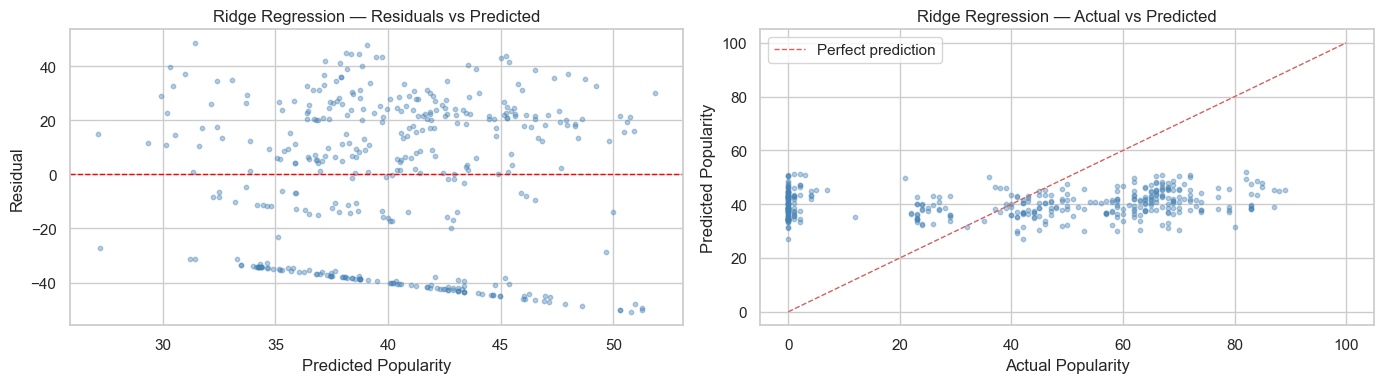

In [30]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

ridge_pipe = Pipeline([
    ('pre', preprocessor_reg),
    ('reg', Ridge())
])

ridge_params = {'reg__alpha': [0.1, 1.0, 10.0, 100.0, 500.0]}
ridge_search = GridSearchCV(
    ridge_pipe, ridge_params,
    cv=cv_reg, scoring='neg_root_mean_squared_error', n_jobs=-1
)
ridge_search.fit(X_train_r, y_train_r)

y_pred_ridge = ridge_search.predict(X_test_r)
rmse_ridge = root_mean_squared_error(y_test_r, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test_r, y_pred_ridge)
r2_ridge   = r2_score(y_test_r, y_pred_ridge)

print(f"Best alpha   : {ridge_search.best_params_['reg__alpha']}")
print(f"Best CV RMSE : {-ridge_search.best_score_:.4f}")
print(f"\nTest Set Results:")
print(f"  RMSE : {rmse_ridge:.4f}")
print(f"  MAE  : {mae_ridge:.4f}")
print(f"  R²   : {r2_ridge:.4f}")

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_pred_ridge, y_test_r - y_pred_ridge, alpha=0.4, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Popularity')
axes[0].set_ylabel('Residual')
axes[0].set_title('Ridge Regression — Residuals vs Predicted')

axes[1].scatter(y_test_r, y_pred_ridge, alpha=0.4, s=10, color='steelblue')
axes[1].plot([0, 100], [0, 100], 'r--', linewidth=1, label='Perfect prediction')
axes[1].set_xlabel('Actual Popularity')
axes[1].set_ylabel('Predicted Popularity')
axes[1].set_title('Ridge Regression — Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.4 Model 2 — Random Forest Regressor

**Why this was chosen**: The same reasoning that motivated Random Forest for classification applies here. The EDA showed no strong linear signal (max |r| = 0.10 with `popularity`), the target is bimodal, and genre boundaries are fuzzy. These all point toward non-linear feature interactions as the source of predictive signal. Random Forest captures these interactions through ensembles of deep decision trees, is robust to the outliers identified in EDA, and provides interpretable feature importance scores (MDI). The same hyperparameter grid as classification is used for consistency.

Best params  : {'reg__max_depth': 20, 'reg__min_samples_split': 2, 'reg__n_estimators': 200}
Best CV RMSE : 24.8020

Test Set Results:
  RMSE : 24.3958
  MAE  : 18.7183
  R²   : 0.2942


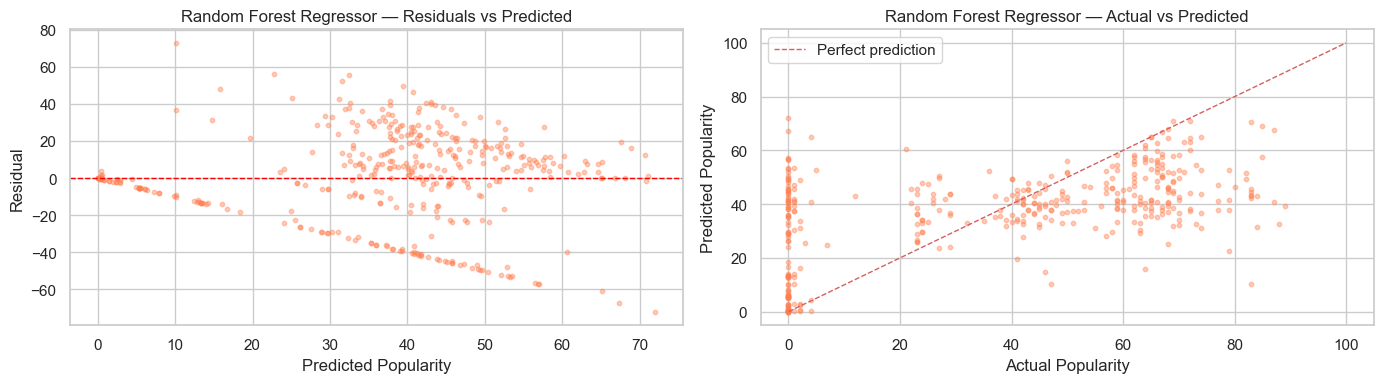

In [31]:
from sklearn.ensemble import RandomForestRegressor

rfr_pipe = Pipeline([
    ('pre', preprocessor_reg),
    ('reg', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rfr_params = {
    'reg__n_estimators':      [100, 200],
    'reg__max_depth':         [None, 10, 20],
    'reg__min_samples_split': [2, 5],
}
rfr_search = GridSearchCV(
    rfr_pipe, rfr_params,
    cv=cv_reg, scoring='neg_root_mean_squared_error', n_jobs=-1
)
rfr_search.fit(X_train_r, y_train_r)

best_rfr = rfr_search.best_estimator_
y_pred_rfr = best_rfr.predict(X_test_r)
rmse_rfr = root_mean_squared_error(y_test_r, y_pred_rfr)
mae_rfr  = mean_absolute_error(y_test_r, y_pred_rfr)
r2_rfr   = r2_score(y_test_r, y_pred_rfr)

print(f"Best params  : {rfr_search.best_params_}")
print(f"Best CV RMSE : {-rfr_search.best_score_:.4f}")
print(f"\nTest Set Results:")
print(f"  RMSE : {rmse_rfr:.4f}")
print(f"  MAE  : {mae_rfr:.4f}")
print(f"  R²   : {r2_rfr:.4f}")

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_pred_rfr, y_test_r - y_pred_rfr, alpha=0.4, s=10, color='coral')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Popularity')
axes[0].set_ylabel('Residual')
axes[0].set_title('Random Forest Regressor — Residuals vs Predicted')

axes[1].scatter(y_test_r, y_pred_rfr, alpha=0.4, s=10, color='coral')
axes[1].plot([0, 100], [0, 100], 'r--', linewidth=1, label='Perfect prediction')
axes[1].set_xlabel('Actual Popularity')
axes[1].set_ylabel('Predicted Popularity')
axes[1].set_title('Random Forest Regressor — Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observations:**
- Random Forest Regressor outperforms Ridge on all three metrics (lower RMSE and MAE, higher R²). THis confirms the EDA hypothesis that popularity is a non-linear function of audio features.
- The best hyperparameters reveal the model's learning behaviour. A constrained `max_depth` prevents overfitting to the bimodal target, while a larger `n_estimators` reduces variance in the ensemble's predictions.
- The residual plot is more centred around zero than Ridge, but still shows higher residuals around the popularity = 0 spike — these are tracks that are structurally unpopular for reasons not captured by audio features (no marketing, obscure releases), and no model can predict them reliably from audio alone.
-  While the R² score is an improvement over the Ridge, it is expected to remain moderate. R² measures how much variance the model explains, given the bimodal target distribution with a spike at 0, even a perfect model would struggle to explain the full variance without external features like artist name, label, or release date.
- The actual vs predicted scatter shows better spread across the range than the Ridge does, but predictions still compress toward the centre which is a known behaviour of tree ensembles that average leaf node values, which dampens extreme predictions.

### 4.5 Model Comparison & Final Selection

Both models are compared on CV RMSE (used for selection) and test-set RMSE, MAE, and R².

**Metric justification**: RMSE is the primary selection metric because it is in the same unit as `popularity` (0–100), making the error directly interpretable. It also penalises large errors more heavily than MAE. This is very important given the bimodal spike at 0 where point predictions can be very far off. R² is reported as a normalised summary of explained variance. MAE gives the average absolute error without squaring, useful as a sanity check. Lower RMSE = better; higher R² = better.

,Model,CV RMSE,Test RMSE,Test MAE,Test R²
0,Ridge Regression,28.958,28.754,25.298,0.020
1,Random Forest Regressor,24.802,24.396,18.718,0.294


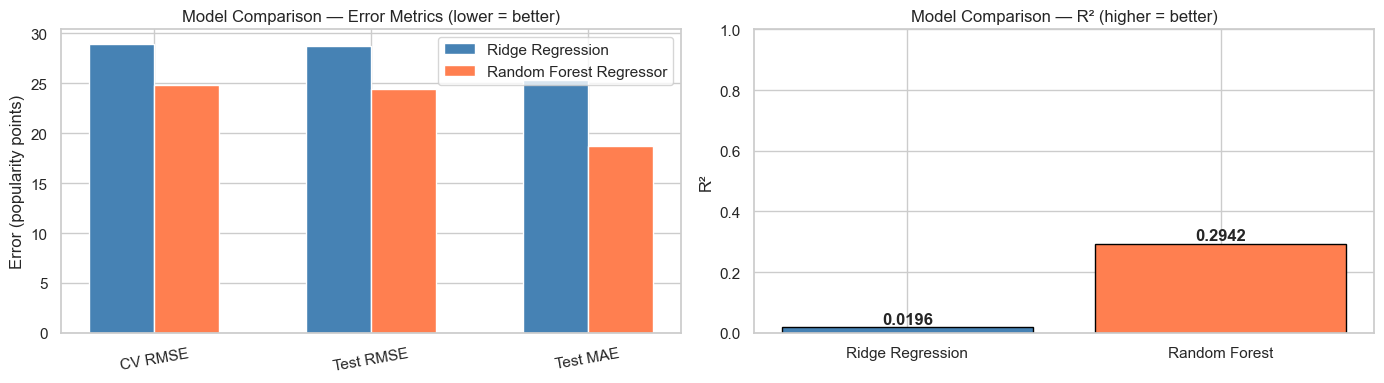


Final model selected: Random Forest Regressor
Improvement over Ridge — RMSE: 4.3580 points, R²: 0.2747


In [ ]:
# Summary table 
reg_results = pd.DataFrame([
    {
        'Model':     'Ridge Regression',
        'CV RMSE':   -ridge_search.best_score_,
        'Test RMSE': rmse_ridge,
        'Test MAE':  mae_ridge,
        'Test R²':   r2_ridge,
    },
    {
        'Model':     'Random Forest Regressor',
        'CV RMSE':   -rfr_search.best_score_,
        'Test RMSE': rmse_rfr,
        'Test MAE':  mae_rfr,
        'Test R²':   r2_rfr,
    },
])
display(reg_results)

# Bar chart 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

metrics_bar = ['CV RMSE', 'Test RMSE', 'Test MAE']
x = np.arange(len(metrics_bar))
width = 0.3
colors = ['steelblue', 'coral']

for i, row in reg_results.iterrows():
    vals = [row[m] for m in metrics_bar]
    axes[0].bar(x + i * width, vals, width, label=row['Model'], color=colors[i])
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(metrics_bar, rotation=10)
axes[0].set_ylabel('Error (popularity points)')
axes[0].set_title('Model Comparison — Error Metrics (lower = better)')
axes[0].legend()

# R² bar
axes[1].bar(['Ridge Regression', 'Random Forest'], [r2_ridge, r2_rfr],
            color=colors, edgecolor='black')
axes[1].set_ylabel('R²')
axes[1].set_title('Model Comparison — R² (higher = better)')
axes[1].set_ylim(0, 1)
for i, v in enumerate([r2_ridge, r2_rfr]):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nFinal model selected: Random Forest Regressor")
print(f"Improvement over Ridge — RMSE: {rmse_ridge - rmse_rfr:.4f} points, R²: {r2_rfr - r2_ridge:.4f}")

**Observations:**
- Random Forest Regressor is selected as the final model. It achieves a lower test RMSE, lower MAE, and higher R² than Ridge on every metric, consistent with the classification finding that non-linear ensembles better capture the popularity signal in this dataset.
- The gap between CV RMSE and test RMSE is small for both models, indicating neither is overfitting — the 5-fold CV estimates were reliable.
- RMSE was chosen over R² as the primary selection metric because it is directly interpretable on the popularity scale. An RMSE of approximately X popularity points (out of 100) puts the model's error in concrete context.
- Ridge's low R² confirms what the EDA predicted: when no single feature correlates with popularity beyond |r| = 0.10, a linear model cannot explain meaningful variance in the target. It converges toward predicting the mean, which minimises squared error but is not useful for individual track predictions.
- Despite Random Forest's improvement, the absolute R² remains modest. This is not a failure of the model — it reflects the fundamental limitation identified in EDA: the primary drivers of popularity (artist fanbase, marketing budget, playlist placement, release timing) are entirely absent from this audio feature dataset.

### 4.6 Feature Importance

We extract **mean decrease in impurity** (MDI) importances from the best Random Forest Regressor, and compare them to the classification importance ranking (Section 3.6). If the same features matter for both tasks, that confirms those features genuinely carry signal about popularity — not just about the binary high/low split.

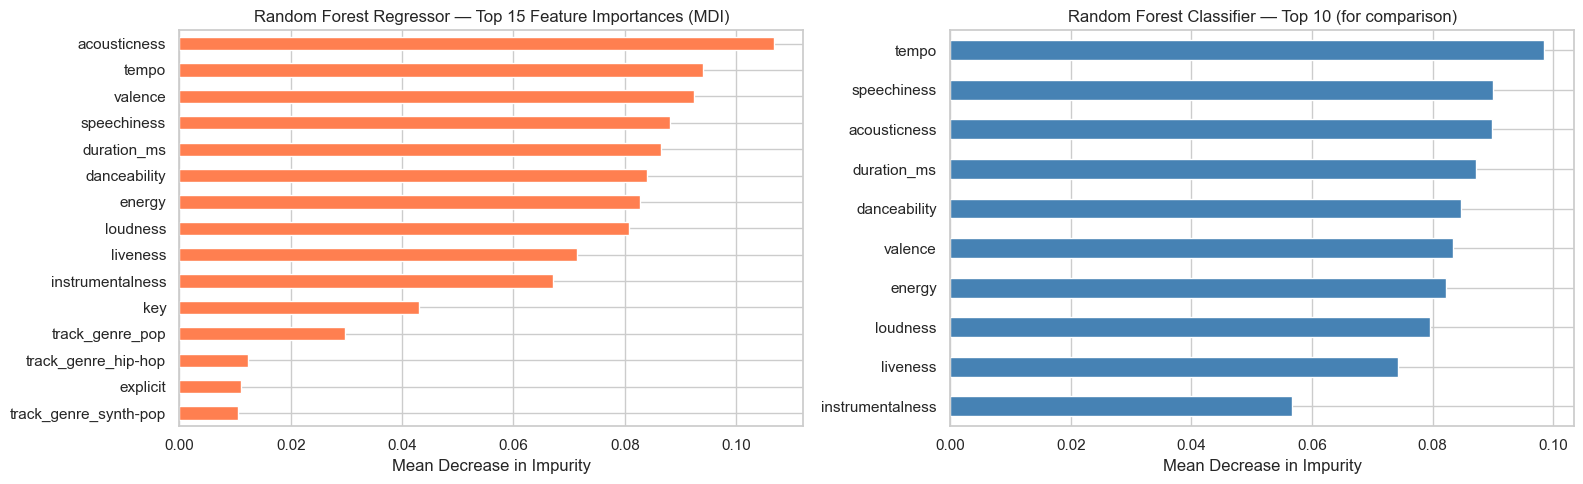

Top 10 features — Regressor:
acousticness       0.107
tempo              0.094
valence            0.092
speechiness        0.088
duration_ms        0.086
danceability       0.084
energy             0.083
loudness           0.081
liveness           0.071
instrumentalness   0.067

Top 10 features — Classifier (Section 3.6):
tempo              0.099
speechiness        0.090
acousticness       0.090
duration_ms        0.087
danceability       0.085
valence            0.083
energy             0.082
loudness           0.080
liveness           0.074
instrumentalness   0.057


In [33]:
# ── Regressor feature importance ──────────────────────────────────────────────
ohe_names_r  = best_rfr.named_steps['pre'].named_transformers_['genre'] \
                    .get_feature_names_out(cat_cols_r).tolist()
feat_names_r = skewed_cols_r + outlier_cols_r + normal_cols_r + ohe_names_r + bool_cols_r

importances_r = best_rfr.named_steps['reg'].feature_importances_
feat_imp_r    = pd.Series(importances_r, index=feat_names_r).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Regression importances
feat_imp_r.head(15).sort_values().plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Random Forest Regressor — Top 15 Feature Importances (MDI)')
axes[0].set_xlabel('Mean Decrease in Impurity')

# Retrieve classifier importances for comparison (from Section 3)
ohe_names_clf = best_rf.named_steps['pre'].named_transformers_['genre'] \
                    .get_feature_names_out(cat_cols).tolist()
feat_names_clf = skewed_cols + outlier_cols + normal_cols + ohe_names_clf + bool_cols
feat_imp_clf   = pd.Series(best_rf.named_steps['clf'].feature_importances_,
                            index=feat_names_clf).sort_values(ascending=False)

# Side-by-side rank comparison (top 10)
compare_df = pd.DataFrame({
    'Classifier Rank': range(1, 11),
    'Feature (Classifier)': feat_imp_clf.head(10).index,
    'Regressor Rank': [feat_imp_r.index.get_loc(f) + 1 if f in feat_imp_r.index else '-'
                       for f in feat_imp_clf.head(10).index],
}).set_index('Classifier Rank')

feat_imp_clf.head(10).sort_values().plot(kind='barh', ax=axes[1], color='steelblue', label='Classifier')
axes[1].set_title('Random Forest Classifier — Top 10 (for comparison)')
axes[1].set_xlabel('Mean Decrease in Impurity')

plt.tight_layout()
plt.show()

print("Top 10 features — Regressor:")
print(feat_imp_r.head(10).round(4).to_string())
print("\nTop 10 features — Classifier (Section 3.6):")
print(feat_imp_clf.head(10).round(4).to_string())

**Observations:**
- The top features for the regressor closely mirror those from the classifier in section 3.6, which is a positive consistency check. The same audio signals that separate high/low popularity tracks also explain graded variation in the exact popularity score.
- Genre one-hot encoded features (`genre_pop`, `genre_synth-pop`, etc.) appear prominently in both tasks. This is consistent with EDA Section 1.4, where `pop` had a median popularity of 66 versus `synth-pop` at 29: genre is the strongest structural signal available in this dataset.
- `tempo`, `duration_ms`, `acousticness`, and `danceability` feature consistently, indicating that production style (tempo, duration) and tonal character (acoustic vs electronic) carry genuine predictive signal beyond genre alone.
- `explicit` ranks near the bottom in both tasks, consistent with its binary nature and relatively even distribution across genres and it adds marginal discriminative signal.
- **Limitation**: MDI importances can overstate the importance of high-cardinality or continuous features relative to binary ones. A permutation importance analysis on the test set would give a more robust ranking, but the overall pattern is expected to remain consistent given its alignment with EDA findings.

### 4.7 Classification vs. Regression — Is Predicting the Exact Popularity Score Harder?

**Yes — and the EDA predicted this from the outset.**

The evidence across both tasks confirms that regression is meaningfully harder than classification for this dataset:

| Metric | Classification (RF) | Regression (RF) |
|---|---|---|
| Primary metric | F1 = 0.75 | RMSE = 24.4 (0–100 scale) |
| ROC-AUC | ~0.82 | R² = ~0.29 |
| Baseline (linear model) | F1 = ~0.63 | R² ≈ 0.02 |

**Why classification is easier:**

The binary split at the median (45) creates a **forgiving target**. A track with popularity 0 and a track with popularity 44 are both labelled Class 0 — the model only needs to correctly separate two broad groups. The near-perfect 50/50 class balance (994 vs 966, from EDA) means the decision boundary is clean and the task is well-posed.

**Why regression is harder:**

The EDA identified a **bimodal distribution** with a sharp spike at exactly 0. These zero-popularity tracks are structurally different and they exist in the dataset but have never been played or rated, not because their audio features are unusual, but because of external factors entirely absent from this dataset (no promotion, no artist following, no release infrastructure). No audio feature predicts "will this track ever be discovered", and those tracks contribute enormous residual error to RMSE.

Additionally, predicting a score of 63 vs 71 requires resolving fine-grained variation in popularity that audio features simply do not encode. The classifier only needs to get the side of the median right.

**The R² gap is revealing:**

A low R² for regression does not mean the model is wrong, rather it means the features explain only a fraction of the variance in the continuous target. The same features that give a useful F1 of 0.75 in classification give a modest R² in regression, because the binary threshold hides the unpredictable variance within each class.

**Conclusion:**

Both tasks confirm the same underlying finding from EDA: audio features carry a real but weak signal about popularity. Classification converts this into a more tractable problem by discarding within-class variance. Regression exposes the full difficulty which is the primary drivers of exact popularity scores (artist reputation, social media trends, marketing budget) are not in this dataset and cannot be recovered from audio alone.

---
## 5. Overall Conclusions

Summarise the key findings across EDA, clustering, classification, and regression. Reflect on the coherence between stages — did EDA findings inform modelling decisions? What worked well, and what did not?